# 따릉이 2025 데이터 통합 분석

이 노트북은 서울 공공자전거 '따릉이'의 2025년 월별 대여 이력 데이터를 기반으로 전처리, 집계, 그리고 연간 이용 패턴을 분석하는 과정을 포함하고 있습니다. 각 단계별 상세 내용은 다음과 같습니다.

---

## 1. 항목별 설명

### 1-1. 환경 설정 (드라이브 마운트·경로·폰트·라이브러리·함수)

이 단계에서는 노트북 실행에 필요한 환경을 설정합니다. Google Drive 마운트, 데이터 및 출력 경로 설정, 한글 폰트 설치, 데이터 처리 및 시각화 라이브러리 로드, 분석 상수 정의, 그리고 데이터 전처리 및 집계에 사용될 사용자 정의 함수들을 정의합니다. 처음 노트북 진입 시 필히 실행되어야 할 항목입니다.

### 1-2. 단일 월 EDA — 원본 데이터 탐색 및 품질 확인

특정 한 달의 따릉이 대여 이력 원본 데이터를 로드하여 탐색적 데이터 분석(EDA)을 수행합니다. 데이터의 구조와 특성을 파악합니다. 데이터 기본 정보 확인, 수치형/범주형 데이터 분포 시각화, 결측치 분석 및 이상치 탐지, 논리적 오류 검사 등을 할 수 있습니다.

### 1-3. 단일 월 전처리 및 집계 CSV 저장

1단계에서 확인된 데이터 품질 문제(결측치, 이상치, 논리 오류 등)를 해결하고, 연간 분석을 위해 표준화된 월별 집계 데이터 파일를 생성합니다. 원본 데이터를 로드하여 정제하고, 분석에 필요한 파생 변수를 생성한 뒤, 속도 이상치 제거 과정을 거쳐 최종 집계 데이터를 CSV 파일로 저장합니다.

### 1-4. 전체 월(2501 ~ 2512) 일괄 처리

2단계에서 검증된 전처리 및 집계 로직을 2025년 전체 12개 월 데이터에 대해 자동으로 반복 적용합니다. 이를 통해 모든 월별 집계 CSV 파일들을 생성하고 저장합니다.

### 1-5. 연간 통합 분석 — 이용 패턴·추이·교차 분석

3단계에서 생성된 12개의 월별 집계 CSV 파일들을 통합하여 2025년 전체 따릉이 이용 데이터를 구축합니다. 이 통합 데이터를 기반으로 연간 이용 패턴, 월별 추이, 연령대/시간대/거리구간/요일별 교차 분석 등을 수행하여 따릉이 이용 특성을 종합적으로 파악하고 시각화합니다.

## 2. 사용 목적 별 노트북 사용방법

환경 설정 셀 실행 후 목적에 맞게 아래 내용 따라 실행

### 2-1. 월별 RAW 데이터 확인 및 특정 월 집계 CSV 파일 생성

***단일 월 EDA*** 항목과 ***단일 월 전처리 및 저장*** 항목을 실행합니다.

### 2-2. 12개월 집계 CSV 파일 생성

***전체 월 일괄 처리*** 항목을 실행합니다.

### 2-3. 연간 통합 분석

***연간 통합 분석*** 항목을 실행합니다.  
12개월치 집계 CSV 파일이 미리 존재해야 하며, 주요 EDA 내용은 해당 항목에서 확인 가능합니다.

## 0. 환경 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR   = '/content/drive/MyDrive/[코드잇] DA16 초급프로젝트_3팀'
DATA_DIR   = f'{BASE_DIR}/데이터/공공데이터2/0. 따릉이_대여이력 정보'
OUTPUT_DIR = f'{BASE_DIR}/데이터/집계'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'DATA_DIR:   {DATA_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

DATA_DIR:   /content/drive/MyDrive/[코드잇] DA16 초급프로젝트_3팀/데이터/공공데이터2/0. 따릉이_대여이력 정보
OUTPUT_DIR: /content/drive/MyDrive/[코드잇] DA16 초급프로젝트_3팀/데이터/집계


In [ ]:
!apt-get install -y fonts-nanum > /dev/null 2>&1
print('폰트 설치 완료')

폰트 설치 완료


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Y축에 , 붙이는 용
import matplotlib.font_manager as fm
import seaborn as sns
import os, re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [ ]:
# 파일 명에 들어가는 2501~2512 만들기, zfill로 앞에 0 채워서 2자리 만드는 것
MONTHS    = [f'25{str(m).zfill(2)}' for m in range(1, 13)]

# 월 매핑
MONTH_MAP = {
    '2501':'1월','2502':'2월','2503':'3월','2504':'4월',
    '2505':'5월','2506':'6월','2507':'7월','2508':'8월',
    '2509':'9월','2510':'10월','2511':'11월','2512':'12월'
}

# 시간대 항목 정렬 순서
TIME_ORDER = ['심야','새벽','아침','오전','낮','오후','저녁','밤']

# 연령대 항목 정렬 순서
AGE_ORDER  = ['10대이하','20대','30대','40대','50대','60대이상']

# 요일 매핑
DOW_MAP    = {0:'월',1:'화',2:'수',3:'목',4:'금',5:'토',6:'일'}

# 요일 항목 정렬 순서
DOW_ORDER  = ['월','화','수','목','금','토','일']

# 거리 구간 항목 정렬 순서
DIST_ORDER = ['1km미만','1~3km','3~5km','5~10km','10km이상']

# 사용 컬럼 정의
USECOLS = [
    '자전거번호', '대여일시', '반납일시',
    '이용시간(분)', '이용거리(M)',
    '생년', '성별', '이용자종류', '자전거구분'
]

# 처음에 csv read 할 때 pandas가 자동으로 타입을 추론하는데 미리 설정하면 메모리 절약, /N과 같은 결측치는 int에서 처리가 안되기 때문에 float으로 변경
DTYPE_MAP = {
    '자전거번호':   'str',
    '이용시간(분)': 'float64',
    '이용거리(M)':  'float64',
    '생년':         'float64',
    '성별':         'str',
    '이용자종류':   'category',
    '자전거구분':   'category',
}

# 집계 키 설정
BASIC_KEYS = ['대여월', '연령대', '시간대', '대여요일', '주말여부', '거리구간']

print('분석 상수 설정 완료')

분석 상수 설정 완료


In [ ]:
# 함수 정의 셀
# 매 월마다 처리해야 하기에 함수로 정의하여 사용

# 데이터 전처리용 함수
def clean_data(df):
    log = {'원본': len(df)}
    df = df.drop_duplicates()
    log['중복제거 후 건수'] = len(df)
    df = df.dropna(subset=['대여일시', '반납일시', '생년', '이용시간(분)', '이용거리(M)'])
    log['결측제거 후 건수'] = len(df)
    df['대여일시'] = pd.to_datetime(df['대여일시'], errors='coerce')
    df['반납일시'] = pd.to_datetime(df['반납일시'], errors='coerce')
    df = df.dropna(subset=['대여일시', '반납일시'])
    df = df[df['반납일시'] >= df['대여일시']] #반납 대여 날짜가 정상(True)인 것만 남기고 버린다.
    log['날짜오류 처리 후 건수'] = len(df)
    df = df[(df['이용시간(분)'] > 0) & (df['이용시간(분)'] <= 1440)] # 24시간 초과인 것은 반납을 까먹은 것으로 파악하여 실제 이용과 괴리가 있으니 제거
    log['이용시간 처리 후 건수'] = len(df)
    df = df[df['이용거리(M)'] > 0]
    log['이용거리 처리 후 건수'] = len(df)
    df = df[(df['생년'] >= 1945) & (df['생년'] <= 2011)]
    log['생년 처리 후 건수'] = len(df)
    df['성별'] = df['성별'].str.upper()
    return df, log

# 파생변수 생성용 함수
def add_features(df):
    df = df.copy()
    df['이용시간(분)'] = df['이용시간(분)'].astype('int64')
    df['생년']        = df['생년'].astype('int64')
    df['나이'] = (2025 - df['생년']).astype('int64')
    df['연령대'] = pd.cut(
        df['나이'],
        bins=[0, 19, 29, 39, 49, 59, 120],
        labels=['10대이하', '20대', '30대', '40대', '50대', '60대이상']
    )
    df['대여월']   = df['대여일시'].dt.month.astype('int64')
    df['대여요일'] = df['대여일시'].dt.dayofweek.astype('int64')
    df['주말여부'] = df['대여요일'].isin([5, 6])
    hour = df['대여일시'].dt.hour
    # pd.cut은 오른쪽을 포함하는데 right=False를 사용하면 오른쪽 제외한다
    df['시간대'] = pd.cut(
        hour,
        bins=[0, 3, 6, 9, 12, 15, 18, 21, 24],
        labels=['심야', '새벽', '아침', '오전', '낮', '오후', '저녁', '밤'],
        right=False
    )
    df['이용거리_km'] = (df['이용거리(M)'] / 1000).round(3).astype('float64')
    # pd.cut은 왼쪽 경계값은 제외하는데 include_lowest = True면 왼쪽 경계값도 포함한다.
    df['거리구간'] = pd.cut(
        df['이용거리_km'],
        bins=[0, 1, 3, 5, 10, 9999],
        labels=['1km미만', '1~3km', '3~5km', '5~10km', '10km이상'],
        include_lowest=True
    )
    df['속도_kmh'] = (df['이용거리_km'] / (df['이용시간(분)'] / 60)).round(2).astype('float64')
    return df

# 집계용 함수
# observed=True 해야 데이터가 없는 조합은 집계하지 않음
def aggregate_basic(df):
    return (
        df.groupby(BASIC_KEYS, observed=True)
        .agg(
            이용건수           = ('자전거번호',    'count'),
            평균_이용시간      = ('이용시간(분)', 'mean'),
            중앙값_이용시간    = ('이용시간(분)', 'median'),
            평균_이용거리_km   = ('이용거리_km',  'mean'),
            중앙값_이용거리_km = ('이용거리_km',  'median'),
            평균_속도_kmh      = ('속도_kmh',     'mean'),
        )
        .round(2)
        .reset_index()
    )


print('함수 정의 완료 (clean_data / add_features / aggregate_basic)')

함수 정의 완료 (clean_data / add_features / aggregate_basic)


## 1. 단일 월 EDA

선택한 월의 원본 데이터를 탐색·확인 상단  
`MONTH` 값을 입력하여 분석대상 월을 선택

In [ ]:
MONTH = '2505'   # 분석할 월 설정 (2501 ~ 2512)

In [ ]:
matched = [
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if re.search(rf'_{MONTH}\.csv$', f)
]
assert matched, f'파일 없음: MONTH={MONTH}' # assert는 뒤에 조건이 오는데 True면 코드 진행, False면 AssertionError발생(,뒤에 오류 메세지 작성)
FILEPATH = matched[0]

print(f'분석 대상: {MONTH_MAP.get(MONTH)} ({MONTH})')
print(f'파일: {os.path.basename(FILEPATH)}')
print(f'크기: {os.path.getsize(FILEPATH)/1e6:.0f} MB')

분석 대상: 5월 (2505)
파일: 서울특별시 공공자전거 대여이력 정보_2505.csv
크기: 726 MB


In [ ]:
with open(FILEPATH, 'rb') as f:
    df_raw = pd.read_csv(f, encoding='cp949')
print(f'로드 완료: {len(df_raw):,}행 x {df_raw.shape[1]}열')

로드 완료: 3,859,379행 x 17열


### 1-1. 기본 탐색

데이터의 구조와 분포를 파악

In [ ]:
print(f'행수: {len(df_raw):,}')
print(f'컬럼수: {df_raw.shape[1]}')
print(f'\n컬럼 목록:')
for col in df_raw.columns:
    print(f'  {col}')

행수: 1,965,170
컬럼수: 17

컬럼 목록:
  자전거번호
  대여일시
  대여 대여소번호
  대여 대여소명
  대여거치대
  반납일시
  반납대여소번호
  반납대여소명
  반납거치대
  이용시간(분)
  이용거리(M)
  생년
  성별
  이용자종류
  대여대여소ID
  반납대여소ID
  자전거구분


In [ ]:
type_info = pd.DataFrame({
    'dtype':     df_raw.dtypes,
    '유일값 수': df_raw.nunique()
})
print(type_info.to_string())

            dtype    유일값 수
자전거번호      object    38892
대여일시       object  1205969
대여 대여소번호    int64     2770
대여 대여소명    object     2770
대여거치대       int64        2
반납일시       object  1208358
반납대여소번호    object     2778
반납대여소명     object     2778
반납거치대      object        3
이용시간(분)     int64      608
이용거리(M)   float64   440177
생년         object      154
성별         object        5
이용자종류      object        3
대여대여소ID    object     2770
반납대여소ID    object     2778
자전거구분      object        2


In [ ]:
num_cols = ['이용시간(분)', '이용거리(M)']
print('=== 수치형 기술통계 ===')
print(df_raw[num_cols].describe().round(2))

=== 수치형 기술통계 ===
          이용시간(분)     이용거리(M)
count  3859379.00  3859379.00
mean        22.68     2584.97
std         27.48     3166.80
min          0.00        0.00
25%          6.00      842.99
50%         12.00     1520.00
75%         28.00     2958.92
max       1374.00   354851.61


In [ ]:
# 범주형 데이터 종류별 비율 확인

cat_cols = ['성별', '이용자종류', '자전거구분']
for col in cat_cols:
    val_count = df_raw[col].value_counts(dropna=False, normalize=True).mul(100).round(2)
    print(f'[{col}]')
    for val, pct in val_count.items():
        print(f'  {str(val):15s}: {pct:.2f}%')
    print()

[성별]
  M              : 46.78%
  F              : 27.36%
  \N             : 23.32%
  nan            : 2.53%
  m              : 0.01%
  f              : 0.00%

[이용자종류]
  내국인            : 98.81%
  비회원            : 0.97%
  외국인            : 0.21%

[자전거구분]
  일반자전거          : 97.45%
  새싹자전거          : 2.55%



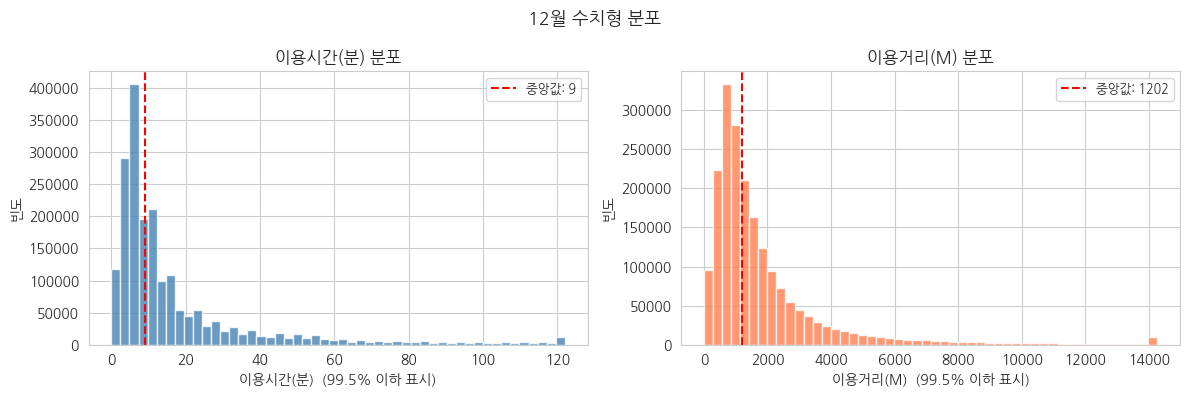

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'coral']

# zip은 iterable 객체들(리스트나 튜플 등)을 인자로 받아서 새로운 iterable 반환
for ax, col, color in zip(axes, num_cols, colors):
    data     = df_raw[col].dropna()
    clip_val = data.quantile(0.995)
    ax.hist(data.clip(upper=clip_val), bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'중앙값: {data.median():.0f}')  # 축 기준 수직선 그리는 함수(평균 등 특정값을 시각적으로 강조할 때 사용)
    ax.set_title(f'{col} 분포')
    ax.set_xlabel(f'{col}  (99.5% 이하 표시)')
    ax.set_ylabel('빈도')
    ax.legend(fontsize=9)

plt.suptitle(f'{MONTH_MAP.get(MONTH)} 수치형 분포', fontsize=13)
plt.tight_layout()
plt.show()

[이용시간(분)과 이용거리(M)의 분포를 확인]
- 이용시간 중앙값: **9분** / 이용거리 중앙값: **1202m**
- 단시간·단거리 이용이 대부분이고 일부 장시간·장거리 이용은 극소수이다.
- 이후 전처리 단계에서 이용시간 0분 이하·1,440분 초과, 이용거리 0m 이하를 제거 기준으로 설정한다.

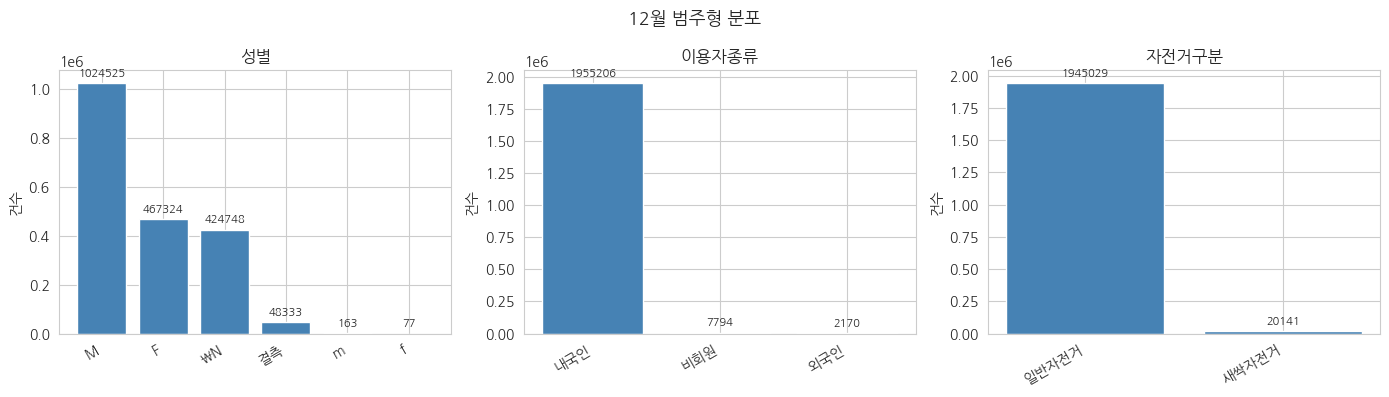

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, cat_cols):
    val_count = df_raw[col].fillna('결측').value_counts()
    bars = ax.bar(val_count.index.astype(str), val_count.values, color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    ax.set_title(f'{col}')
    ax.set_ylabel('건수')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle(f'{MONTH_MAP.get(MONTH)} 범주형 분포', fontsize=13)
plt.tight_layout()
plt.show()

[성별·이용자종류·자전거구분의 분포를 확인]
- 성별: 남성 **1024525건**, 여성 **467324건**, 결측 **48333건** — 남성 이용자 비중이 높다.
- 이용자종류: **내국인**이 **1955206건**으로 비중이 가장 높다.
- 자전거구분: **일반자전거**가 **1945029건**으로 비중이 가장 높다.

### 1-2. 결측치 분석

결측치의 규모와 함께 어떤 값이 결측을 유발했는지, 특정 그룹에 집중되어 있는지 파악

In [ ]:
print('=== 원시 결측값 (진짜 NaN) ===')
raw_null = df_raw.isnull().sum()
print(raw_null[raw_null > 0].to_string() if raw_null.sum() > 0 else '없음')

print('\n=== \\N 값 (MySQL NULL 표기) ===') # csv 파일에 null이 아닌 \N으로 된 값이 있는데 MySQL에서 null 데이터 가져오면서 생긴 것으로 추측
for col in df_raw.columns:
    n = (df_raw[col] == '\\N').sum()
    if n > 0:
        print(f'  {col}: {n:,}건 ({n/len(df_raw)*100:.2f}%)')

=== 원시 결측값 (진짜 NaN) ===
생년      765
성별    48333

=== \N 값 (MySQL NULL 표기) ===
  반납대여소번호: 10,826건 (0.55%)
  반납대여소명: 10,826건 (0.55%)
  반납거치대: 12,393건 (0.63%)
  생년: 116,709건 (5.94%)
  성별: 424,748건 (21.61%)
  반납대여소ID: 10,826건 (0.55%)


In [ ]:
with open(FILEPATH, 'rb') as f:
    df = pd.read_csv(f, encoding='cp949', na_values=['\\N']) # na_values는 특정 문자열을 null로 바꿔준다.
df['생년'] = pd.to_numeric(df['생년'], errors='coerce')
print('na_values 적용 완료 (\\N → NaN)')

na_values 적용 완료 (\N → NaN)


=== 결측 현황 (na_values 적용 후) ===
            결측수  결측률(%)
성별       473081   24.07
생년       117474    5.98
반납거치대     12393    0.63
반납대여소명    10826    0.55
반납대여소번호   10826    0.55
반납대여소ID   10826    0.55


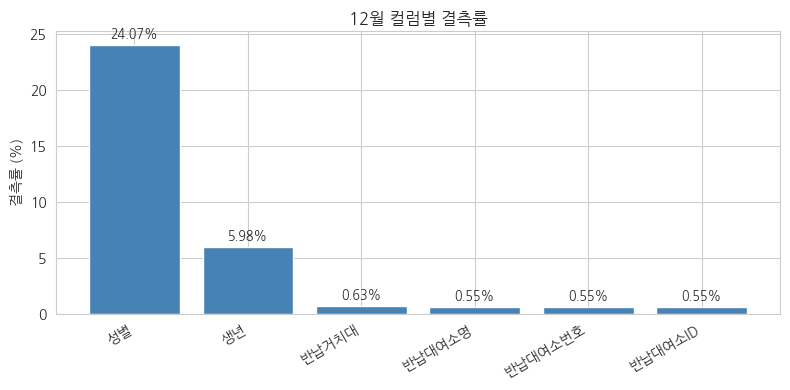

In [ ]:
missing = pd.DataFrame({
    '결측수':    df.isnull().sum(),
    '결측률(%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('결측수', ascending=False)
miss_nz = missing[missing['결측수'] > 0]

print('=== 결측 현황 (na_values 적용 후) ===')
print(miss_nz.to_string() if len(miss_nz) > 0 else '결측값 없음')

if len(miss_nz) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(miss_nz.index, miss_nz['결측률(%)'], color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
    ax.set_title(f'{MONTH_MAP.get(MONTH)} 컬럼별 결측률')
    ax.set_ylabel('결측률 (%)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

[컬럼별 결측률을 확인]
- 결측이 가장 많은 컬럼은 **성별**로 **24.07%**의 결측률을 보인다.

In [ ]:
print('=== 성별 결측 경향성: 이용자종류별 비교 ===')
gender_null = df.groupby('이용자종류', dropna=False)['성별'].apply(
    lambda x: pd.Series({
        '전체수':    len(x),
        '결측수':    x.isnull().sum(),
        '결측률(%)': round(x.isnull().mean() * 100, 2)
    })
).unstack() # 데이터 프레임 재구조화
print(gender_null.to_string())

# 비회원인데 0.33%의 성별 데이터가 있는 경우는 어떻게 해석되는 것이 맞는가? -> 피드백 : 오류로 보고 제거해도 무방할 정도의 규모

=== 성별 결측 경향성: 이용자종류별 비교 ===
             전체수       결측수  결측률(%)
이용자종류                             
내국인    1955206.0  463143.0   23.69
비회원       7794.0    7768.0   99.67
외국인       2170.0    2170.0  100.00


In [ ]:
has_return = df['반납대여소번호'].notna()
no_return  = df['반납대여소번호'].isna()

print('=== 반납대여소 결측 vs 정상: 이용시간 비교 ===')
comp = pd.DataFrame({
    '반납대여소 있음': df.loc[has_return, '이용시간(분)'].describe(),
    '반납대여소 없음': df.loc[no_return,  '이용시간(분)'].describe(),
}).round(1)
print(comp.to_string())
print(f'\n반납대여소 결측 건수: {no_return.sum():,}건 ({no_return.mean()*100:.2f}%)')

=== 반납대여소 결측 vs 정상: 이용시간 비교 ===
        반납대여소 있음  반납대여소 없음
count  1954344.0   10826.0
mean        17.7      34.1
std         24.2      39.4
min          0.0       2.0
25%          5.0      10.0
50%          9.0      20.0
75%         19.0      53.0
max       1439.0     830.0

반납대여소 결측 건수: 10,826건 (0.55%)


### 1-3. 이상치 분석

IQR 기준으로 이상치를 탐지하고 어떤 패턴이 있는지 파악

In [ ]:
print('=== IQR 기반 이상치 탐지 ===\n')
iqr_info = {}

for col in num_cols:
    data    = df[col].dropna()
    q1, q3  = data.quantile(0.25), data.quantile(0.75)
    iqr     = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out   = ((data < lower) | (data > upper)).sum()
    iqr_info[col] = (lower, upper)

    print(f'[{col}]')
    print(f'  Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}')
    print(f'  하한={lower:.1f}  상한={upper:.1f}')
    print(f'  실제 범위: {data.min():.1f} ~ {data.max():.1f}')
    print(f'  이상치: {n_out:,}건 ({n_out/len(data)*100:.2f}%)')
    print()

=== IQR 기반 이상치 탐지 ===

[이용시간(분)]
  Q1=5.0  Q3=19.0  IQR=14.0
  하한=-16.0  상한=40.0
  실제 범위: 0.0 ~ 1439.0
  이상치: 221,304건 (11.26%)

[이용거리(M)]
  Q1=716.9  Q3=2120.0  IQR=1403.1
  하한=-1387.7  상한=4224.6
  실제 범위: 0.0 ~ 81816.0
  이상치: 162,984건 (8.29%)



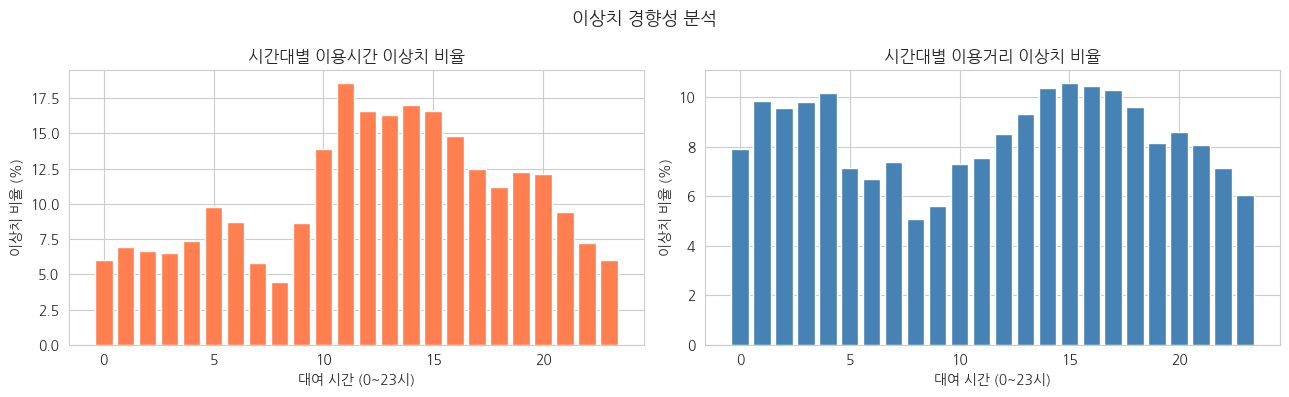

In [ ]:
df['__대여시간__'] = pd.to_datetime(df['대여일시'], errors='coerce').dt.hour

# 앞 셀에서 iqr_info 딕셔너리로 이상치 기준 저장
lower_t, upper_t = iqr_info['이용시간(분)']
lower_d, upper_d = iqr_info['이용거리(M)']

# 대여가 이루어진 시간대 별로 그룹화
# 이상치보다 큰 것을 True, 아닌것을 False로 하여 mean을 써서 상한값보다 큰 비율을 계산
# 0 보다 낮은 값은 전처리 때 제외할테니 하한값에 대해서는 별도로 판단하지 않음
hour_dist_t = df.groupby('__대여시간__')['이용시간(분)'].apply(
    lambda x: round((x > upper_t).mean() * 100, 2))
hour_dist_d = df.groupby('__대여시간__')['이용거리(M)'].apply(
    lambda x: round((x > upper_d).mean() * 100, 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(hour_dist_t.index, hour_dist_t.values, color='coral', edgecolor='white')
axes[0].set_title('시간대별 이용시간 이상치 비율')
axes[0].set_xlabel('대여 시간 (0~23시)')
axes[0].set_ylabel('이상치 비율 (%)')

axes[1].bar(hour_dist_d.index, hour_dist_d.values, color='steelblue', edgecolor='white')
axes[1].set_title('시간대별 이용거리 이상치 비율')
axes[1].set_xlabel('대여 시간 (0~23시)')
axes[1].set_ylabel('이상치 비율 (%)')

plt.suptitle('이상치 경향성 분석', fontsize=13)
plt.tight_layout()
plt.show()

df.drop(columns=['__대여시간__'], inplace=True)

[시간대별 이상치 비율을 확인]
- 이용시간 이상치는 **11시**에 가장 높은 비율로 나타난다. 심야·새벽 시간대에 반납을 잊고 장시간 대여한 케이스가 많은 것으로 추정된다.
- 이용거리 이상치는 **04시**와 **15시**에 상대적으로 높다.
- 이상치는 IQR 기준 및 논리적 오류(24시간 초과 등)를 적용하여 전처리 단계에서 제거한다.

In [ ]:
print('=== 논리적 오류 현황 ===\n')

rent_dt = pd.to_datetime(df['대여일시'], errors='coerce')
rtn_dt  = pd.to_datetime(df['반납일시'], errors='coerce')
valid   = rent_dt.notna() & rtn_dt.notna()

checks = [
    ('이용시간 0분 이하',          (df['이용시간(분)'] <= 0).sum()),
    ('이용거리 0m 이하',           (df['이용거리(M)'] <= 0).sum()),
    ('이용시간 24시간 초과',       (df['이용시간(분)'] > 1440).sum()),
    ('반납 < 대여 (날짜 역전)',    (valid & (rtn_dt < rent_dt)).sum()),
    ('비현실적 생년 (범위 외)',     (df['생년'].notna() & ((df['생년'] < 1945) | (df['생년'] > 2011))).sum()),
    ('생년 결측',                  df['생년'].isna().sum()),
]

for label, count in checks:
    print(f'  {label:25s}: {count:>7,}건  ({count/len(df)*100:.2f}%)')

=== 논리적 오류 현황 ===

  이용시간 0분 이하               :   1,472건  (0.07%)
  이용거리 0m 이하               :  30,654건  (1.56%)
  이용시간 24시간 초과             :       0건  (0.00%)
  반납 < 대여 (날짜 역전)          :       0건  (0.00%)
  비현실적 생년 (범위 외)           :  11,967건  (0.61%)
  생년 결측                    : 117,474건  (5.98%)


## 2. 단일 월 전처리 및 저장

EDA에서 확인한 결측·이상치·논리 오류를 처리하고 집계 CSV를 생성

| # | 처리 항목 | 기준 |
|---|-----------|------|
| 1 | 완전 중복 제거 | 모든 컬럼 동일 |
| 2 | 핵심 컬럼 결측 제거 | 생년·이용시간·이용거리·날짜 NaN |
| 3 | 날짜 오류 제거 | 반납 < 대여 |
| 4 | 이용시간 필터 | 0분 초과 ~ 1440분 이하 |
| 5 | 이용거리 필터 | 0m 초과 |
| 6 | 생년 범위 필터 | 1945 ~ 2011 |
| 7 | 성별 대소문자 통일 | m→M, f→F |
| 8 | 속도 이상치 제거 | 파생변수 생성 후 IQR 기반 |

In [ ]:
with open(FILEPATH, 'rb') as f:
    df_clean = pd.read_csv(
        f, encoding='cp949',
        usecols=USECOLS, dtype=DTYPE_MAP, # 미리 정의한 컬럼만!!
        parse_dates=['대여일시','반납일시'], # 대여일시, 반납일시 날짜/시간 형식으로 변경
        na_values=['\\N']
    )
df_clean, clean_log = clean_data(df_clean)

print('=== 전처리 단계별 행수 변화 ===')
prev = clean_log['원본']
for step, cnt in clean_log.items():
    removed = prev - cnt if step != '원본' else 0
    print(f'  {step:10s}: {cnt:>8,}행  (제거 {removed:,}건)')
    prev = cnt

total = clean_log['원본'] - clean_log['생년 처리 후 건수']
print(f'\n총 제거: {total:,}건 ({total/clean_log["원본"]*100:.2f}%)')

=== 전처리 단계별 행수 변화 ===
  원본        : 3,859,379행  (제거 0건)
  중복제거 후 건수 : 3,859,378행  (제거 1건)
  결측제거 후 건수 : 3,600,028행  (제거 259,350건)
  날짜오류 처리 후 건수: 3,600,028행  (제거 0건)
  이용시간 처리 후 건수: 3,597,749행  (제거 2,279건)
  이용거리 처리 후 건수: 3,557,911행  (제거 39,838건)
  생년 처리 후 건수: 3,537,582행  (제거 20,329건)

총 제거: 321,797건 (8.34%)


In [ ]:
df_feat = add_features(df_clean)
print(f'파생변수 생성 완료: {df_feat.shape}')

파생변수 생성 완료: (1806358, 18)


In [ ]:
speed  = df_feat['속도_kmh']
q1, q3 = speed.quantile(0.25), speed.quantile(0.75)
iqr    = q3 - q1
lower  = q1 - 1.5 * iqr
upper  = q3 + 1.5 * iqr

before   = len(df_feat)
df_feat  = df_feat[(df_feat['속도_kmh'] >= lower) & (df_feat['속도_kmh'] <= upper)]
removed  = before - len(df_feat)

print(f'속도 IQR: Q1={q1:.2f}  Q3={q3:.2f}  하한={lower:.2f}  상한={upper:.2f} km/h')
print(f'속도 이상치 제거: {removed:,}건 ({removed/before*100:.2f}%)')
print(f'필터 후 행수: {len(df_feat):,}')

속도 IQR: Q1=6.37  Q3=10.81  하한=-0.29  상한=17.47 km/h
속도 이상치 제거: 29,523건 (1.63%)
필터 후 행수: 1,776,835


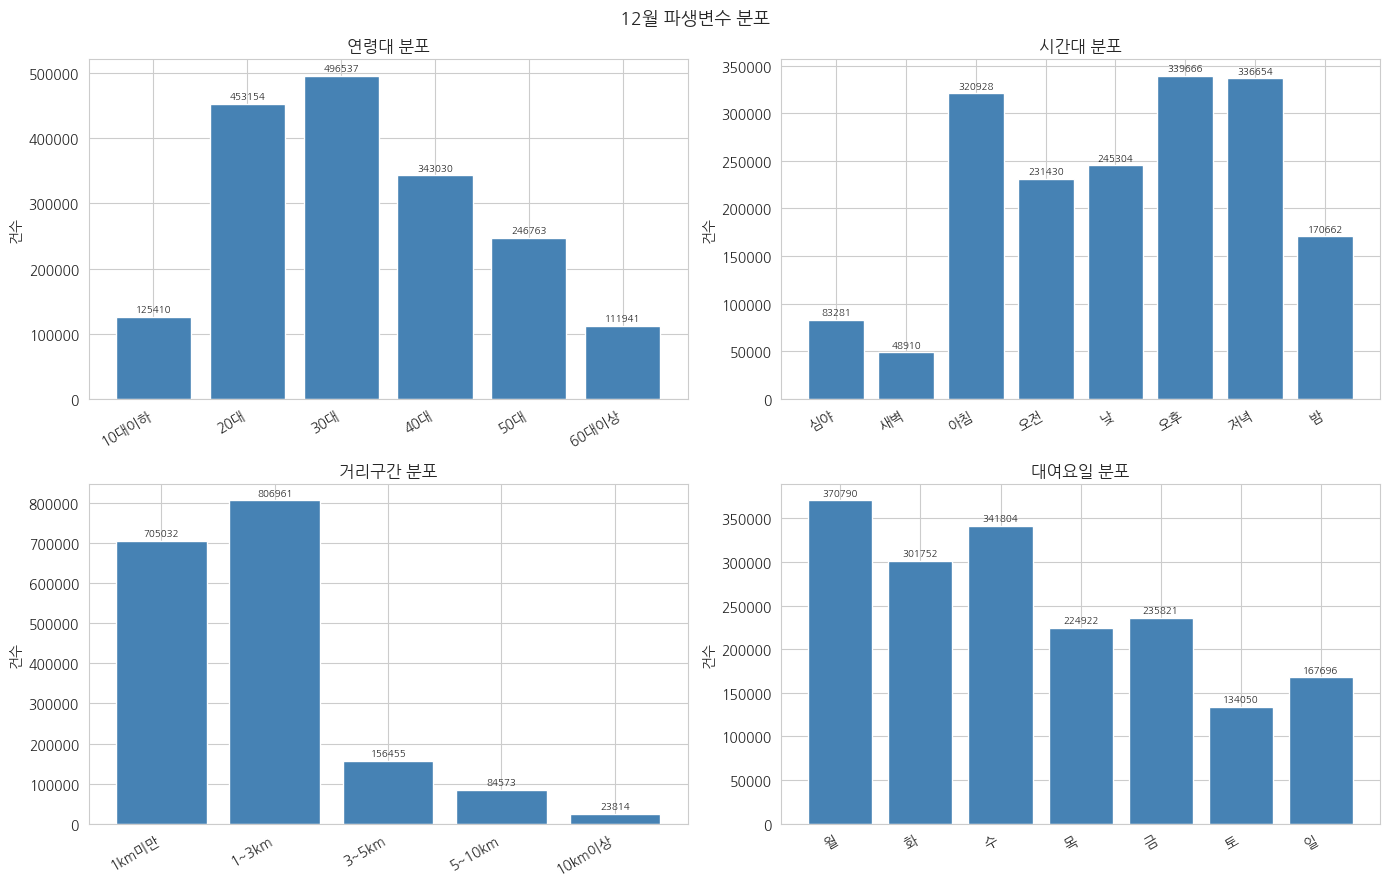

In [ ]:
derived = ['연령대', '시간대', '거리구간', '대여요일']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
orders = [None, TIME_ORDER, None, None]

for ax, col, order in zip(axes.flatten(), derived, orders):
    val_count = df_feat[col].value_counts().sort_index()
    if order:
        val_count = val_count.reindex(order)

    # '대여요일' 컬럼의 경우 숫자를 요일 이름으로 매핑
    if col == '대여요일':
        val_count.index = val_count.index.map(DOW_MAP)
        val_count = val_count.reindex(DOW_ORDER)

    bars = ax.bar(val_count.index.astype(str), val_count.values, color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%d', padding=2, fontsize=7)
    ax.set_title(f'{col} 분포')
    ax.set_ylabel('건수')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle(f'{MONTH_MAP.get(MONTH)} 파생변수 분포', fontsize=13)
plt.tight_layout()
plt.show()

[전처리 및 파생변수 생성 후 주요 변수의 분포를 확인]
- 연령대: **30대**가 **496537건**으로 가장 높은 비중을 차지한다.
- 시간대: **아침**과 **저녁** 이용이 가장 많으며, 출퇴근 패턴이 반영된 것으로 보인다.
- 거리구간: **1km미만**과 **1~3km** 구간 비중이 가장 높아 따릉이가 단·중거리 이동 수단으로 주로 활용됨을 확인했다.
- 대여요일: **월요일**에 이용이 집중된다.

In [ ]:
df_basic = aggregate_basic(df_feat)
out_basic = f'{OUTPUT_DIR}/집계_기본_{MONTH}.csv'
df_basic.to_csv(out_basic, index=False, encoding='utf-8-sig')

print(f'집계_기본  shape: {df_basic.shape}')
print(f'이용건수 합계: {df_basic["이용건수"].sum():,}')
print(f'저장 완료: {out_basic}')

집계_기본  shape: (1679, 12)
이용건수 합계: 1,776,835
저장 완료: /content/drive/MyDrive/[코드잇] DA16 초급프로젝트_3팀/데이터/집계/집계_기본_2512.csv


## 3. 전체 월 일괄 처리 (2501 ~ 2512)

12개 월 파일을 순서대로 처리하여 집계 CSV를 생성  
이미 저장된 월은 덮어씁니다.

In [ ]:
for MONTH in MONTHS:
    matched = [
        os.path.join(DATA_DIR, f)
        for f in os.listdir(DATA_DIR)
        if re.search(rf'_{MONTH}\.csv$', f)
    ]
    if not matched:
        print(f'  [{MONTH}] 파일 없음, 건너뜀')
        continue
    fp = matched[0]

    with open(fp, 'rb') as f:
        df_m = pd.read_csv(
            f, encoding='cp949',
            usecols=USECOLS, dtype=DTYPE_MAP,
            parse_dates=['대여일시','반납일시'],
            na_values=['\\N']
        )

    df_m, _ = clean_data(df_m)
    df_m    = add_features(df_m)

    spd = df_m['속도_kmh']
    q1, q3 = spd.quantile(0.25), spd.quantile(0.75)
    iqr    = q3 - q1
    df_m   = df_m[(df_m['속도_kmh'] >= q1-1.5*iqr) & (df_m['속도_kmh'] <= q3+1.5*iqr)]

    df_m  = aggregate_basic(df_m)
    out   = f'{OUTPUT_DIR}/집계_기본_{MONTH}.csv'
    df_m.to_csv(out, index=False, encoding='utf-8-sig')
    print(f'  [{MONTH_MAP[MONTH]}] 저장 완료: {df_m["이용건수"].sum():,}건')

print('\n전체 처리 완료')

  [1월] 저장 완료: 1,508,522건
  [2월] 저장 완료: 1,451,599건
  [3월] 저장 완료: 2,586,126건
  [4월] 저장 완료: 3,266,868건
  [5월] 저장 완료: 3,476,123건
  [6월] 저장 완료: 3,632,018건
  [7월] 저장 완료: 3,196,519건
  [8월] 저장 완료: 3,214,472건
  [9월] 저장 완료: 3,607,197건
  [10월] 저장 완료: 3,075,221건
  [11월] 저장 완료: 2,872,970건
  [12월] 저장 완료: 1,776,835건

전체 처리 완료


### 3-1. 전체 월 전처리 결과 건수

12개 월 원본 파일을 재로드하여 단계별 제거 건수를 수집한다.  
CSV는 재저장하지 않으며, `all_logs` 변수에 결과를 저장한다.

In [ ]:
# 전체 12개월 전처리 단계별 건수 수집 (CSV 재저장 없음)
all_logs = []

for MONTH in MONTHS:
    matched = [
        os.path.join(DATA_DIR, f)
        for f in os.listdir(DATA_DIR)
        if re.search(rf'_{MONTH}\.csv$', f)
    ]
    if not matched:
        print(f'[{MONTH_MAP[MONTH]}] 파일 없음, 건너뜀')
        continue

    with open(matched[0], 'rb') as f:
        df_m = pd.read_csv(
            f, encoding='cp949',
            usecols=USECOLS, dtype=DTYPE_MAP,
            parse_dates=['대여일시', '반납일시'],
            na_values=['\\N']
        )

    df_m, log = clean_data(df_m)
    df_m = add_features(df_m)

    spd = df_m['속도_kmh']
    q1, q3 = spd.quantile(0.25), spd.quantile(0.75)
    iqr = q3 - q1
    df_m = df_m[(df_m['속도_kmh'] >= q1 - 1.5*iqr) & (df_m['속도_kmh'] <= q3 + 1.5*iqr)]
    log['속도IQR 처리 후 건수'] = len(df_m)
    log['월'] = MONTH_MAP[MONTH]
    all_logs.append(log)
    print(f'  [{MONTH_MAP[MONTH]}] 원본 {log["원본"]:,}  →  최종 {len(df_m):,}  '
          f'(제거 {log["원본"] - len(df_m):,}건, {(log["원본"]-len(df_m))/log["원본"]*100:.1f}%)')

print('\n전체 로그 수집 완료')

  [1월] 원본 1,704,188  →  최종 1,508,522  (제거 195,666건, 11.5%)
  [2월] 원본 1,629,474  →  최종 1,451,599  (제거 177,875건, 10.9%)
  [3월] 원본 2,876,862  →  최종 2,586,126  (제거 290,736건, 10.1%)
  [4월] 원본 3,630,749  →  최종 3,266,868  (제거 363,881건, 10.0%)
  [5월] 원본 3,859,379  →  최종 3,476,123  (제거 383,256건, 9.9%)
  [6월] 원본 4,024,309  →  최종 3,632,018  (제거 392,291건, 9.7%)
  [7월] 원본 3,536,197  →  최종 3,196,519  (제거 339,678건, 9.6%)
  [8월] 원본 3,559,262  →  최종 3,214,472  (제거 344,790건, 9.7%)
  [9월] 원본 3,992,296  →  최종 3,607,197  (제거 385,099건, 9.6%)
  [10월] 원본 3,407,800  →  최종 3,075,221  (제거 332,579건, 9.8%)
  [11월] 원본 3,186,968  →  최종 2,872,970  (제거 313,998건, 9.9%)
  [12월] 원본 1,965,170  →  최종 1,776,835  (제거 188,335건, 9.6%)

전체 로그 수집 완료


In [ ]:
step_keys = [
    '원본', '중복제거 후 건수', '결측제거 후 건수', '날짜오류 처리 후 건수',
    '이용시간 처리 후 건수', '이용거리 처리 후 건수', '생년 처리 후 건수', '속도IQR 처리 후 건수'
]
step_info = [
    ('원본', '—'),
    ('1',    '완전 중복 제거'),
    ('2',    '핵심 컬럼 결측 제거'),
    ('3',    '날짜 오류 제거'),
    ('4',    '이용시간 필터'),
    ('5',    '이용거리 필터'),
    ('6',    '생년 범위 필터'),
    ('7',    '속도 이상치 제거'),
]

df_log     = pd.DataFrame(all_logs).set_index('월')
total      = df_log[step_keys].sum()
total_orig = int(total['원본'])

print(f'{"단계":<4}  {"처리 항목":<16}  {"처리 후 건수":>14}  {"제거 건수":>12}  {"제거 비율":>8}')
print('-' * 64)

for i, (key, (step_num, label)) in enumerate(zip(step_keys, step_info)):
    cnt = int(total[key])
    rm  = int(total[step_keys[i-1]]) - cnt if i > 0 else 0
    if step_num == '원본':
        print(f'{step_num:<4}  {label:<16}  {cnt:>14,}  {"—":>12}  {"—":>8}')
    else:
        print(f'{step_num:<4}  {label:<16}  {cnt:>14,}  {rm:>12,}  {rm/total_orig*100:>7.2f}%')

print('-' * 64)
total_final = int(total['속도IQR 처리 후 건수'])
total_rm    = total_orig - total_final
print(f'{"최종":<4}  {"":<16}  {total_final:>14,}  {total_rm:>12,}  {total_rm/total_orig*100:>7.2f}%')

단계    처리 항목                    처리 후 건수         제거 건수     제거 비율
----------------------------------------------------------------
원본    —                     37,372,654             —         —
1     완전 중복 제거              37,372,653             1     0.00%
2     핵심 컬럼 결측 제거           34,953,656     2,418,997     6.47%
3     날짜 오류 제거              34,953,656             0     0.00%
4     이용시간 필터               34,929,252        24,404     0.07%
5     이용거리 필터               34,466,698       462,554     1.24%
6     생년 범위 필터              34,264,279       202,419     0.54%
7     속도 이상치 제거             33,664,470       599,809     1.60%
----------------------------------------------------------------
최종                          33,664,470     3,708,184     9.92%


## 4. 연간 통합 분석

월별 집계 CSV 12개를 합쳐 2025년 연간 패턴을 분석  
분석 대상: **20~30대 주요 이용층**의 시간대·이동거리·요일 패턴

### 4-1. 데이터 통합

In [ ]:
basic_list = []
for m in MONTHS:
    path = f'{OUTPUT_DIR}/집계_기본_{m}.csv'
    try:
        with open(path, 'rb') as f:
            basic_list.append(pd.read_csv(f, encoding='utf-8-sig'))
            print(f'  로드: {m}')
    except FileNotFoundError:
        print(f'  없음: {path}')

df_basic = pd.concat(basic_list, ignore_index=True) # 월별 데이터 concat
# 시간대, 연령대 범주형 변환
df_basic['시간대'] = pd.Categorical(df_basic['시간대'], categories=TIME_ORDER, ordered=True)
df_basic['연령대'] = pd.Categorical(df_basic['연령대'], categories=AGE_ORDER,  ordered=True)

print(f'\n집계_기본  shape: {df_basic.shape}')
print(f'전체 이용건수: {df_basic["이용건수"].sum():,}')

  로드: 2501
  로드: 2502
  로드: 2503
  로드: 2504
  로드: 2505
  로드: 2506
  로드: 2507
  로드: 2508
  로드: 2509
  로드: 2510
  로드: 2511
  로드: 2512

집계_기본  shape: (20158, 12)
전체 이용건수: 33,664,470


In [ ]:
print('=== 집계_기본 컬럼 및 타입 ===')
print(df_basic.dtypes)
print()
df_basic.head(5)

=== 집계_기본 컬럼 및 타입 ===
대여월               int64
연령대            category
시간대            category
대여요일              int64
주말여부               bool
거리구간             object
이용건수              int64
평균_이용시간         float64
중앙값_이용시간        float64
평균_이용거리_km      float64
중앙값_이용거리_km     float64
평균_속도_kmh       float64
dtype: object



,대여월,연령대,시간대,대여요일,주말여부,거리구간,이용건수,평균_이용시간,중앙값_이용시간,평균_이용거리_km,중앙값_이용거리_km,평균_속도_kmh
0,1,10대이하,심야,0,False,1km미만,113,8.59,5.0,0.67,0.74,8.03
1,1,10대이하,심야,0,False,1~3km,263,14.45,12.0,1.80,1.73,9.05
2,1,10대이하,심야,0,False,3~5km,64,27.91,24.0,3.85,3.76,9.50
3,1,10대이하,심야,0,False,5~10km,43,53.12,44.0,6.65,6.40,8.83
4,1,10대이하,심야,0,False,10km이상,6,79.00,77.5,12.10,12.40,9.65


### 4-2. 연간 전체 현황

In [ ]:
total = df_basic['이용건수'].sum()
print(f'2025년 총 이용건수: {total:,}건')

age_cnt = df_basic.groupby('연령대', observed=True)['이용건수'].sum().reindex(AGE_ORDER)
print('\n=== 연령대별 이용건수 및 비중 ===')
for age, cnt in age_cnt.items():
    print(f'  {age}: {cnt:>10,}건  ({cnt/total*100:.1f}%)')

2025년 총 이용건수: 33,664,470건

=== 연령대별 이용건수 및 비중 ===
  10대이하:  2,150,203건  (6.4%)
  20대:  9,375,229건  (27.8%)
  30대:  9,795,249건  (29.1%)
  40대:  6,164,239건  (18.3%)
  50대:  4,329,349건  (12.9%)
  60대이상:  1,850,201건  (5.5%)


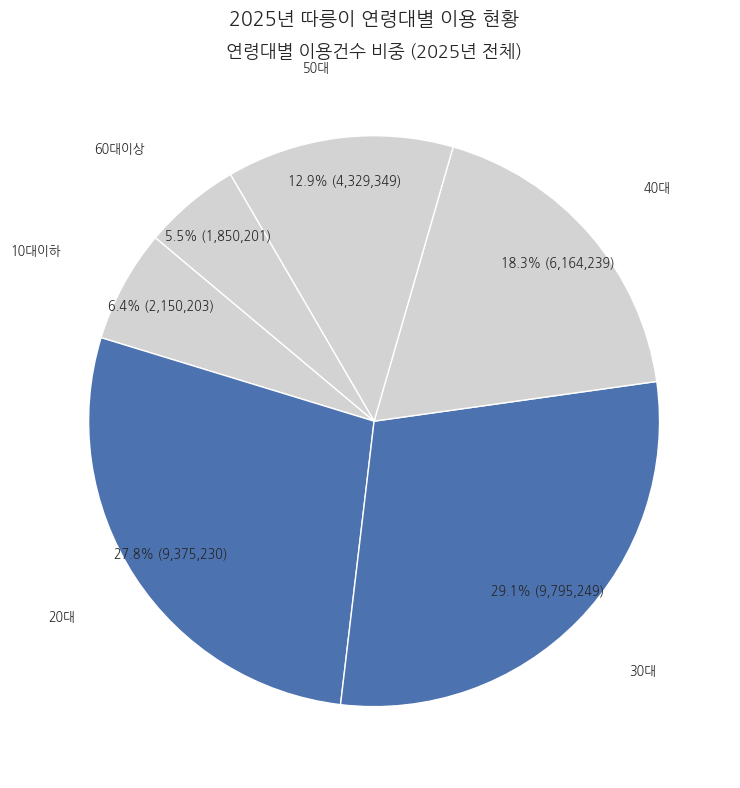

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

def autopct_format(pct):
    absolute = int(np.round(pct/100.*age_cnt.sum()))
    return f'{pct:.1f}% ({absolute:,})'

colors_pie = ['#4C72B0' if a in ['20대','30대'] else '#D3D3D3' for a in age_cnt.index]
ax.pie(age_cnt.values, labels=age_cnt.index, autopct=autopct_format,
            colors=colors_pie, startangle=140, pctdistance=0.85, labeldistance=1.25, textprops={'fontsize': 9})
ax.set_title('연령대별 이용건수 비중 (2025년 전체)', fontsize=13)

plt.suptitle('2025년 따릉이 연령대별 이용 현황', fontsize=14)
plt.tight_layout()
plt.show()

[연령대별 이용 현황을 확인]
- 20대(**27.8%**)와 30대(**29.1%**)가 전체 이용의 절반 이상을 차지하며 주요 이용층임을 확인했다.
- 40대(**18.3%**)가 그 뒤를 잇고, 10대 이하·60대 이상은 상대적으로 낮은 비중을 보인다.
- 이후 분석에서는 20~30대를 주요 분석 대상으로 설정하여 이용 패턴을 심층 분석한다.

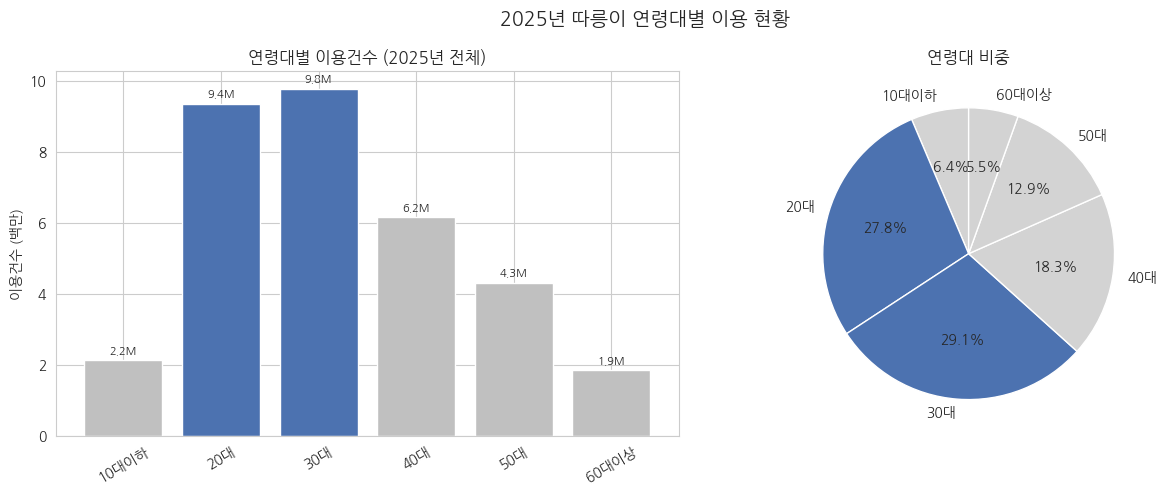

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1e6은 1*10^6. 2e3은 2* 10^3, 단순히 숫자 사용보다 저런 표기법을 더 권장
bars = axes[0].bar(age_cnt.index, age_cnt.values / 1e6,
                   color=['#4C72B0' if a in ['20대','30대'] else '#C0C0C0' for a in age_cnt.index],
                   edgecolor='white') # 20대, 30대만 색 다르게
axes[0].bar_label(bars, fmt='%.1fM', padding=3, fontsize=8)
axes[0].set_title('연령대별 이용건수 (2025년 전체)')
axes[0].set_ylabel('이용건수 (백만)')
axes[0].tick_params(axis='x', rotation=30)

colors_pie = ['#4C72B0' if a in ['20대','30대'] else '#D3D3D3' for a in age_cnt.index]
axes[1].pie(age_cnt.values, labels=age_cnt.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90)
axes[1].set_title('연령대 비중')

plt.suptitle('2025년 따릉이 연령대별 이용 현황', fontsize=14)
plt.tight_layout()
plt.show()

[이용건수와 비중을 추가하여 연령대별 이용 현황을 확인]
- 20대(**27.8%**)와 30대(**29.1%**)가 전체 이용의 절반 이상을 차지하며 주요 이용층임을 확인했다.
- 40대(**18.3%**)가 그 뒤를 잇고, 10대 이하·60대 이상은 상대적으로 낮은 비중을 보인다.
- 이용 건수를 보아도 20대와 30대는 비슷한 정도의 따릉이 이용을 확인할 수 있다.

### 4-3. 월별 이용 추이

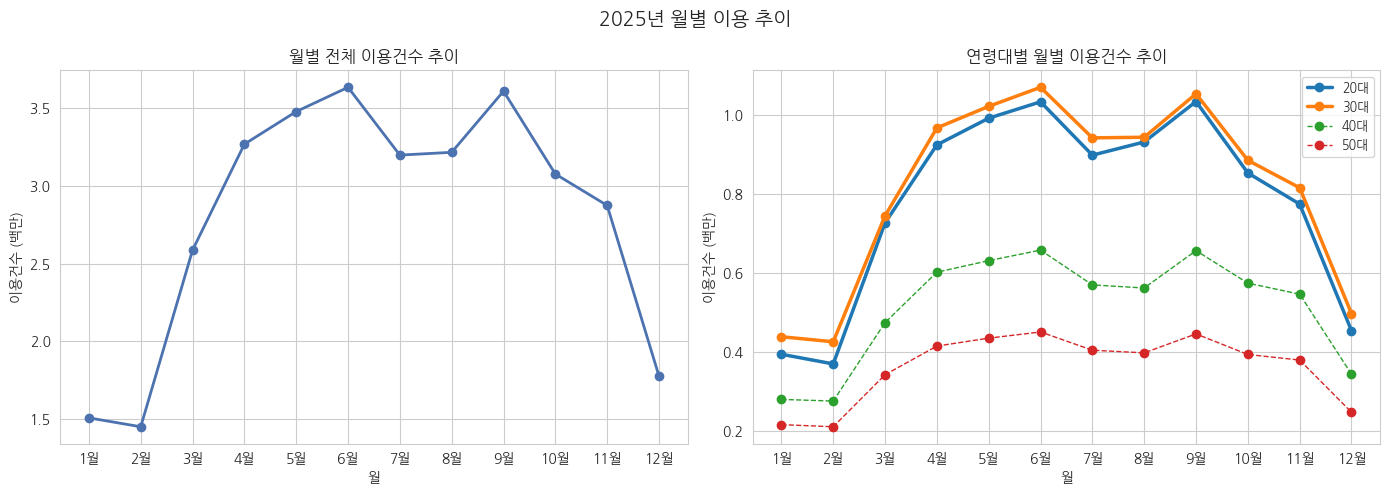

In [ ]:
monthly     = df_basic.groupby('대여월')['이용건수'].sum()
monthly_age = df_basic.groupby(['대여월','연령대'], observed=True)['이용건수'].sum().unstack(fill_value=0) # 대여월, 연령대 값 없는 경우 fill_value로 0으로 채워서 오류 방지

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly.index, monthly.values / 1e6, marker='o', color='#4C72B0', linewidth=2)
axes[0].set_title('월별 전체 이용건수 추이')
axes[0].set_xlabel('월')
axes[0].set_ylabel('이용건수 (백만)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels([f'{m}월' for m in range(1, 13)])

for age in ['20대','30대','40대','50대']:
    if age in monthly_age.columns:
        lw = 2.5 if age in ['20대','30대'] else 1
        ls = '-'  if age in ['20대','30대'] else '--'
        axes[1].plot(monthly_age.index, monthly_age[age] / 1e6,
                     marker='o', label=age, linewidth=lw, linestyle=ls)
axes[1].set_title('연령대별 월별 이용건수 추이')
axes[1].set_xlabel('월')
axes[1].set_ylabel('이용건수 (백만)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([f'{m}월' for m in range(1, 13)])
axes[1].legend(fontsize=9)

plt.suptitle('2025년 월별 이용 추이', fontsize=14)
plt.tight_layout()
plt.show()

[월별 이용건수 추이를 확인]
- 전체 이용건수는 **6월과 7월**에 최고점을 기록하며, **2월**에 최저점을 보인다.
- 봄(3 ~ 5월)과 가을(9 ~ 10월)에 이용이 집중되고 겨울(12~2월)에 감소하는 계절성 패턴이 뚜렷하다.
- 20~30대도 전체와 유사한 월별 추이를 보이며, 계절 영향을 동등하게 받는다.

### 4-4. 시간대별 이용 패턴

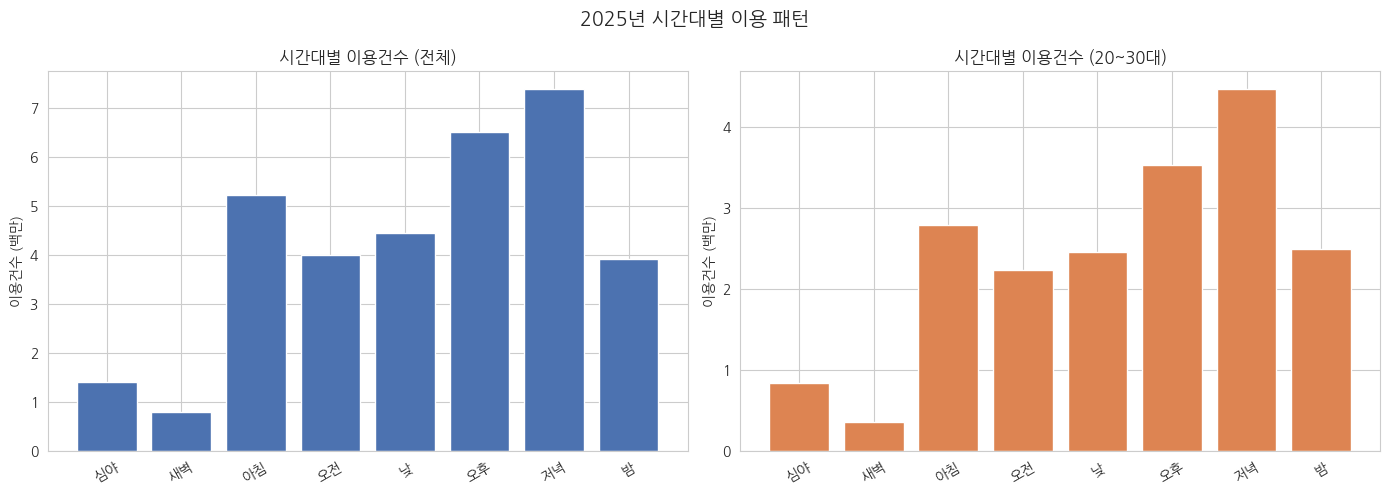


=== 시간대별 이용건수 비중 (20~30대) ===
  심야    :   841,676건  (4.4%)
  새벽    :   360,201건  (1.9%)
  아침    : 2,794,699건  (14.6%)
  오전    : 2,230,434건  (11.6%)
  낮     : 2,461,339건  (12.8%)
  오후    : 3,527,427건  (18.4%)
  저녁    : 4,463,911건  (23.3%)
  밤     : 2,490,791건  (13.0%)


In [ ]:
time_cnt  = df_basic.groupby('시간대', observed=True)['이용건수'].sum().reindex(TIME_ORDER)
df_2030   = df_basic[df_basic['연령대'].isin(['20대', '30대'])]
time_2030 = df_2030.groupby('시간대', observed=True)['이용건수'].sum().reindex(TIME_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(time_cnt.index, time_cnt.values / 1e6, color='#4C72B0', edgecolor='white')
axes[0].set_title('시간대별 이용건수 (전체)')
axes[0].set_ylabel('이용건수 (백만)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(time_2030.index, time_2030.values / 1e6, color='#DD8452', edgecolor='white')
axes[1].set_title('시간대별 이용건수 (20~30대)')
axes[1].set_ylabel('이용건수 (백만)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('2025년 시간대별 이용 패턴', fontsize=14)
plt.tight_layout()
plt.show()

print('\n=== 시간대별 이용건수 비중 (20~30대) ===')
total_2030 = time_2030.sum()
for t, v in time_2030.items():
    print(f'  {t:6s}: {v:>9,}건  ({v/total_2030*100:.1f}%)')

[시간대별 이용건수를 전체와 20~30대로 비교]
- 전체 및 20~30대 모두 **저녁** 시간대와 **오후** 시간대에 이용이 집중되어 있음을 확인했다.
- Y 축 값이 차이가 있어 두 그래프의 직접적인 비교가 아닌 패턴을 확인하는 목적으로 봐야한다.

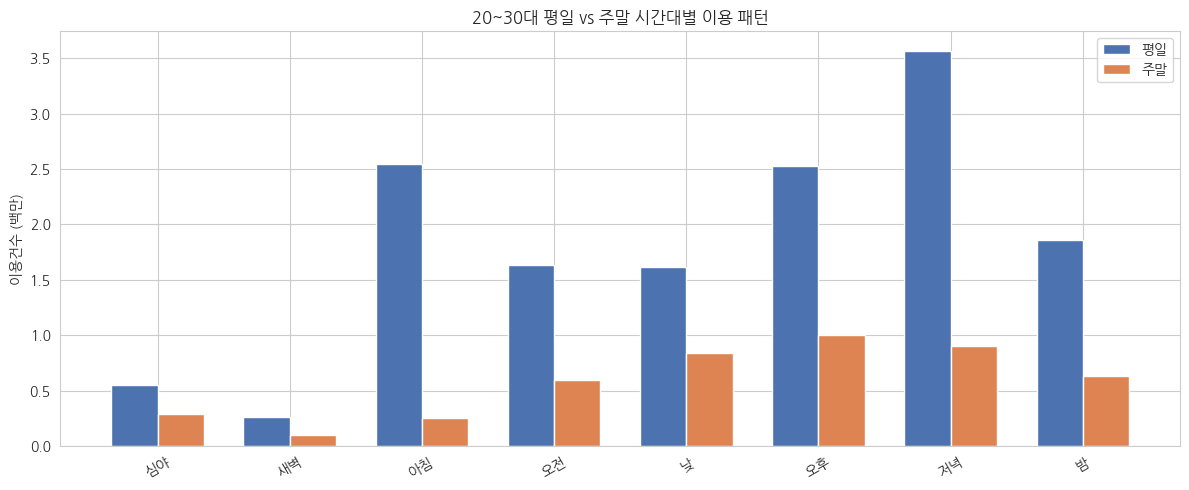

In [ ]:
time_wk = df_2030.groupby(['주말여부', '시간대'], observed=True)['이용건수'].sum().unstack(level=0, fill_value=0)
time_wk.columns = ['평일', '주말']
time_wk = time_wk.reindex(TIME_ORDER)

x = range(len(TIME_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - w/2 for i in x], time_wk['평일'] / 1e6, width=w, label='평일', color='#4C72B0', edgecolor='white')
ax.bar([i + w/2 for i in x], time_wk['주말'] / 1e6, width=w, label='주말', color='#DD8452', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(TIME_ORDER, rotation=30)
ax.set_title('20~30대 평일 vs 주말 시간대별 이용 패턴')
ax.set_ylabel('이용건수 (백만)')
ax.legend()
plt.tight_layout()
plt.show()

[20~30대의 평일·주말 시간대별 이용 패턴 비교]
- 평일은 **저녁** 시간대와 **아침** 시간대에 뚜렷한 피크가 형성되어 출퇴근 이용이 두드러진다.
- 주말은 **오후** 시간대에 이용이 집중되며 여가·운동 목적 이용로 추정된다.
- 평일 총 이용건수가 주말보다 높으나, 단순 합산은 날 수 차이가 반영된 값으로 다음 차트에서 하루 평균으로 이를 보정하여 비교한다.

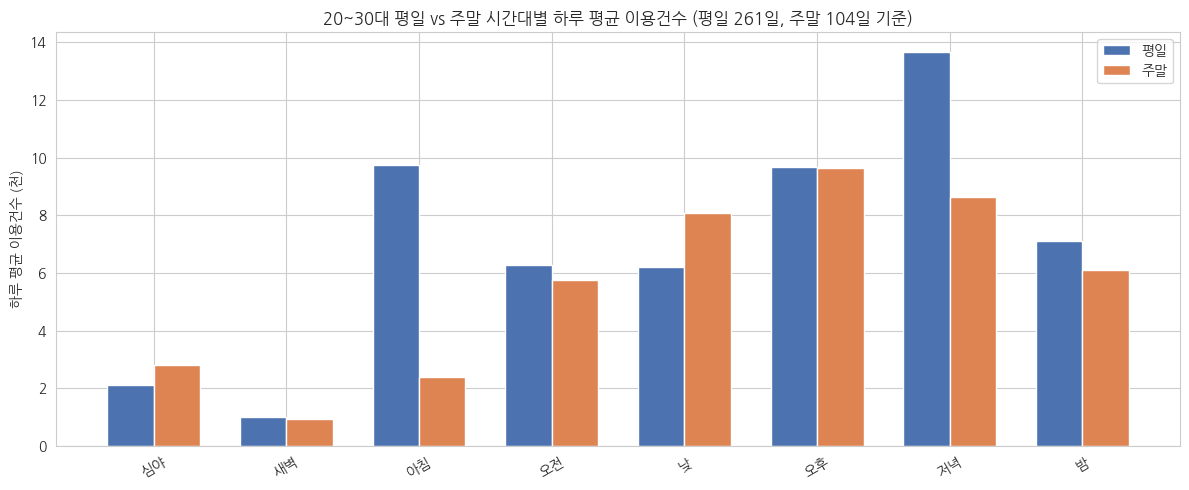


=== 아침 및 저녁 시간대 주중/주말 이용건수 확인 (20~30대) ===
아침 (평일): 9,750건
아침 (주말): 2,404건
아침 (평일-주말 차이): 7,346건
아침 (평일 대비 주말 이용률): 24.7%
아침 (주말 대비 평일 이용률): 405.6%

저녁 (평일): 13,657건
저녁 (주말): 8,648건
저녁 (평일-주말 차이): 5,009건
저녁 (평일 대비 주말 이용률): 63.3%
저녁 (주말 대비 평일 이용률): 157.9%


In [ ]:
dates_2025 = pd.date_range('2025-01-01', '2025-12-31')
n_weekday  = int((dates_2025.dayofweek < 5).sum()) # 평일
n_weekend  = int((dates_2025.dayofweek >= 5).sum()) # 주말

time_wk_avg = time_wk.copy()
time_wk_avg['평일'] = time_wk['평일'] / n_weekday
time_wk_avg['주말'] = time_wk['주말'] / n_weekend

x = range(len(TIME_ORDER))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - w/2 for i in x], time_wk_avg['평일'] / 1e3, width=w, label='평일', color='#4C72B0', edgecolor='white')
ax.bar([i + w/2 for i in x], time_wk_avg['주말'] / 1e3, width=w, label='주말', color='#DD8452', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(TIME_ORDER, rotation=30)
ax.set_title(f'20~30대 평일 vs 주말 시간대별 하루 평균 이용건수 (평일 {n_weekday}일, 주말 {n_weekend}일 기준)')
ax.set_ylabel('하루 평균 이용건수 (천)')
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== 아침 및 저녁 시간대 주중/주말 이용건수 확인 (20~30대) ===')
morning_weekday = time_wk_avg.loc['아침', '평일']
morning_weekend = time_wk_avg.loc['아침', '주말']
evening_weekday = time_wk_avg.loc['저녁', '평일']
evening_weekend = time_wk_avg.loc['저녁', '주말']

print(f"아침 (평일): {morning_weekday:,.0f}건")
print(f"아침 (주말): {morning_weekend:,.0f}건")
print(f"아침 (평일-주말 차이): {(morning_weekday - morning_weekend):,.0f}건")
print(f"아침 (평일 대비 주말 이용률): {(morning_weekend / morning_weekday * 100):.1f}%")
print(f"아침 (주말 대비 평일 이용률): {(morning_weekday / morning_weekend * 100):.1f}%")

print(f"\n저녁 (평일): {evening_weekday:,.0f}건")
print(f"저녁 (주말): {evening_weekend:,.0f}건")
print(f"저녁 (평일-주말 차이): {(evening_weekday - evening_weekend):,.0f}건")
print(f"저녁 (평일 대비 주말 이용률): {(evening_weekend / evening_weekday * 100):.1f}%")
print(f"저녁 (주말 대비 평일 이용률): {(evening_weekday / evening_weekend * 100):.1f}%")

[20~30대의 하루 평균 이용건수로 보정 후 평일·주말 패턴을 비교(평일 261일 / 주말 104일 기준)]
- 평일 **아침** 시간대의 하루 평균은 같은 시간대 평일 대비 **약 4배 이상**의 수준으로, 출근 목적의 사용이 상당수 있음을 추측할 수 있다.
- 평일 출퇴근 피크(아침·오후)는 하루 평균 기준에서도 뚜렷하게 유지된다.

### 4-5. 이동거리 패턴

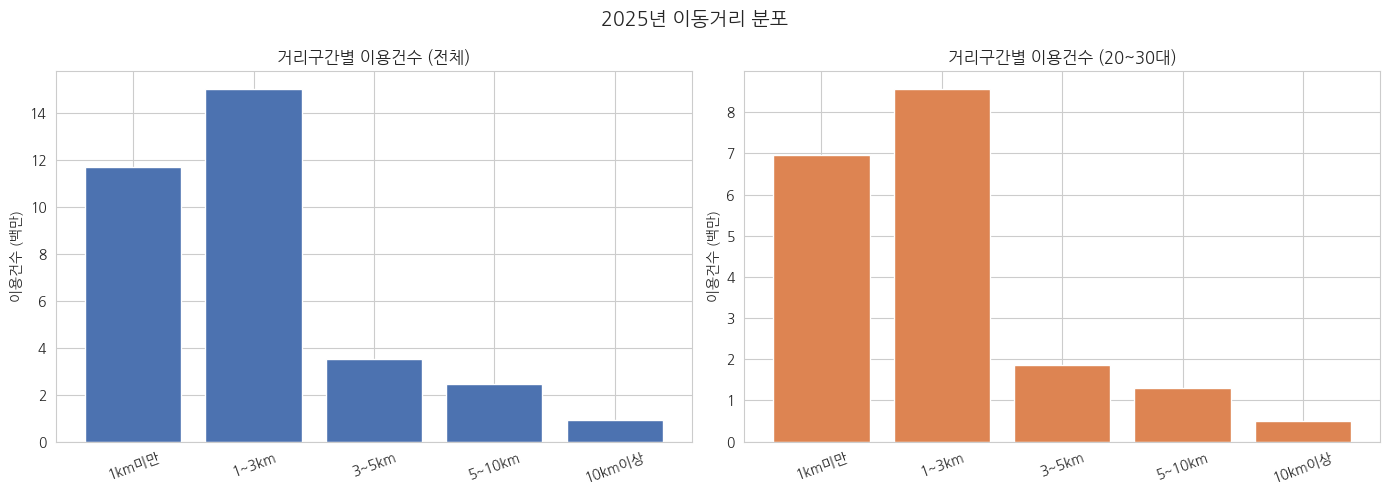


=== 거리구간별 평균 이용시간 (20~30대) ===
거리구간
1km미만      7.7
1~3km     18.1
3~5km     34.8
5~10km    49.8
10km이상    79.8


In [ ]:
dist_all  = df_basic.groupby('거리구간', observed=True)['이용건수'].sum().reindex(DIST_ORDER)
dist_2030 = df_2030.groupby('거리구간',  observed=True)['이용건수'].sum().reindex(DIST_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dist_all.index, dist_all.values / 1e6, color='#4C72B0', edgecolor='white')
axes[0].set_title('거리구간별 이용건수 (전체)')
axes[0].set_ylabel('이용건수 (백만)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(dist_2030.index, dist_2030.values / 1e6, color='#DD8452', edgecolor='white')
axes[1].set_title('거리구간별 이용건수 (20~30대)')
axes[1].set_ylabel('이용건수 (백만)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('2025년 이동거리 분포', fontsize=14)
plt.tight_layout()
plt.show()

print('\n=== 거리구간별 평균 이용시간 (20~30대) ===')
dist_time = df_2030.groupby('거리구간', observed=True).apply(
    lambda x: round((x['평균_이용시간'] * x['이용건수']).sum() / x['이용건수'].sum(), 1)
).reindex(DIST_ORDER)
print(dist_time.to_string())

[거리구간별 이용 분포를 확인]
- **1~3km** 구간 이용이 따릉이 이용의 큰 부분을 차지하고 있으며, **1km미만** 이 그 다음 비중을 차지한다. 따릉이가 단거리 이동 수단으로 주로 활용됨을 확인할 수 있다.
- 주 이용층인 **20~30대**도 전체 분포와 동일한 분포를 보인다.

### 4-6. 요일별 패턴

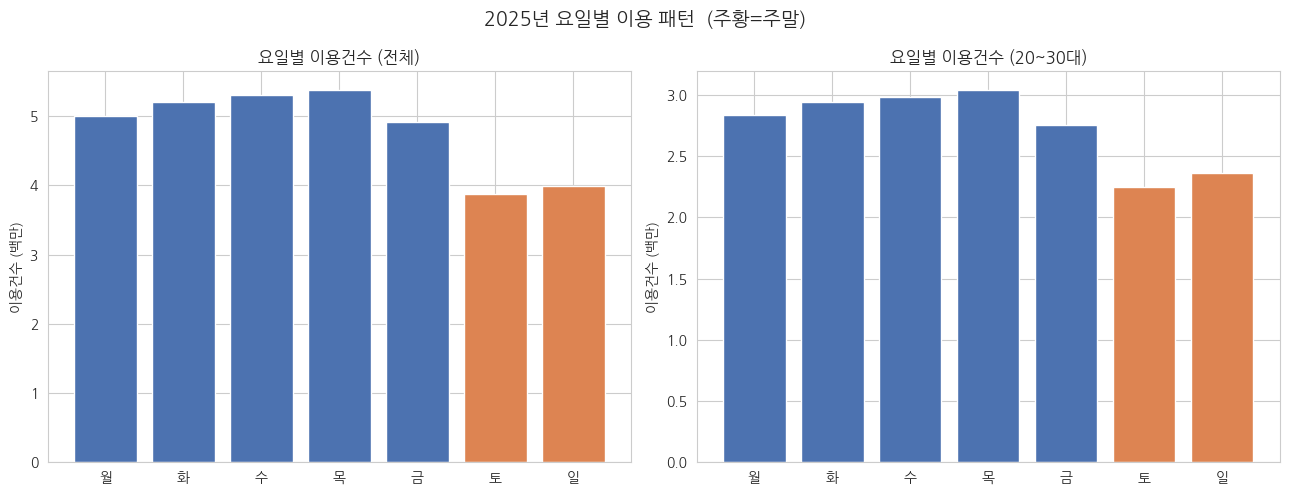

In [ ]:
dow_all  = df_basic.groupby('대여요일')['이용건수'].sum()
dow_2030 = df_2030.groupby('대여요일')['이용건수'].sum()

dow_all.index  = dow_all.index.map(DOW_MAP)
dow_2030.index = dow_2030.index.map(DOW_MAP)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_dow = ['#DD8452' if d in ['토','일'] else '#4C72B0' for d in DOW_ORDER]

axes[0].bar(DOW_ORDER, dow_all.reindex(DOW_ORDER).values / 1e6,
            color=colors_dow, edgecolor='white')
axes[0].set_title('요일별 이용건수 (전체)')
axes[0].set_ylabel('이용건수 (백만)')

axes[1].bar(DOW_ORDER, dow_2030.reindex(DOW_ORDER).values / 1e6,
            color=colors_dow, edgecolor='white')
axes[1].set_title('요일별 이용건수 (20~30대)')
axes[1].set_ylabel('이용건수 (백만)')

plt.suptitle('2025년 요일별 이용 패턴  (주황=주말)', fontsize=14)
plt.tight_layout()
plt.show()

[요일별 이용건수를 확인]
- 주말에 비해 평일의 이동건수가 백만건 가까이 차이가 나는 것을 확인할 수 있다.
- 20~30대도 동일한 패턴을 보인다.

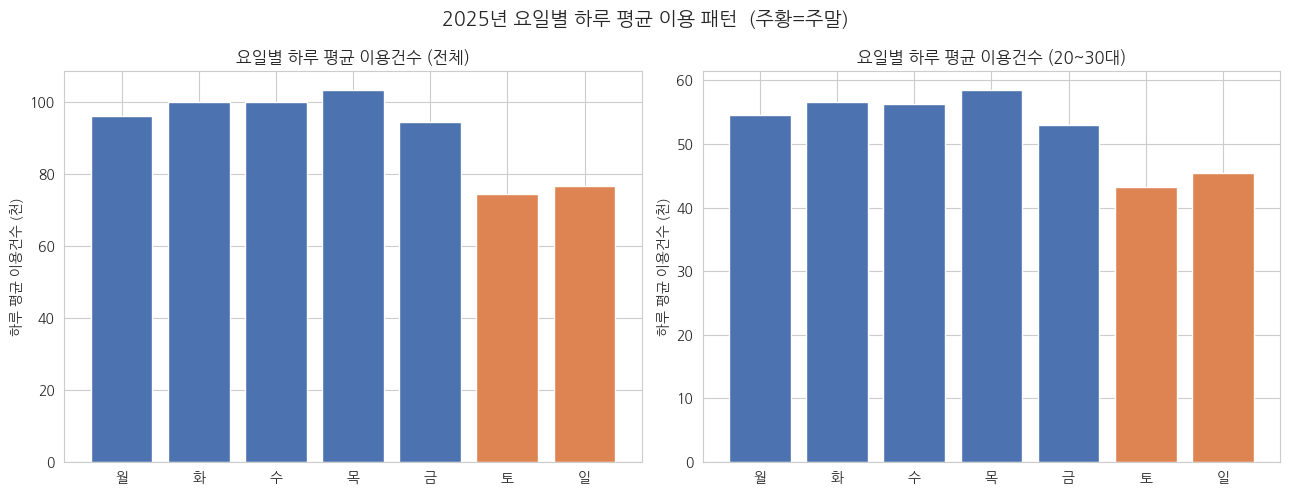

In [ ]:
dow_count = pd.Series(dates_2025.dayofweek).value_counts().sort_index()
dow_count.index = dow_count.index.map(DOW_MAP)

dow_all_avg  = dow_all.reindex(DOW_ORDER)  / dow_count.reindex(DOW_ORDER)
dow_2030_avg = dow_2030.reindex(DOW_ORDER) / dow_count.reindex(DOW_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(DOW_ORDER, dow_all_avg.values / 1e3, color=colors_dow, edgecolor='white')
axes[0].set_title('요일별 하루 평균 이용건수 (전체)')
axes[0].set_ylabel('하루 평균 이용건수 (천)')

axes[1].bar(DOW_ORDER, dow_2030_avg.values / 1e3, color=colors_dow, edgecolor='white')
axes[1].set_title('요일별 하루 평균 이용건수 (20~30대)')
axes[1].set_ylabel('하루 평균 이용건수 (천)')

plt.suptitle('2025년 요일별 하루 평균 이용 패턴  (주황=주말)', fontsize=14)
plt.tight_layout()
plt.show()

[요일별 하루 평균 이용건수를 확인]
- 기존 요일별 이용건수도 평일과 주말의 비교가 아닌 각 요일의 비교이므로 평균 이용건수의 그래프도 요일별 이용건수와 유사한 형태를 보인다.

### 4-7. 20~30대 교차 분석

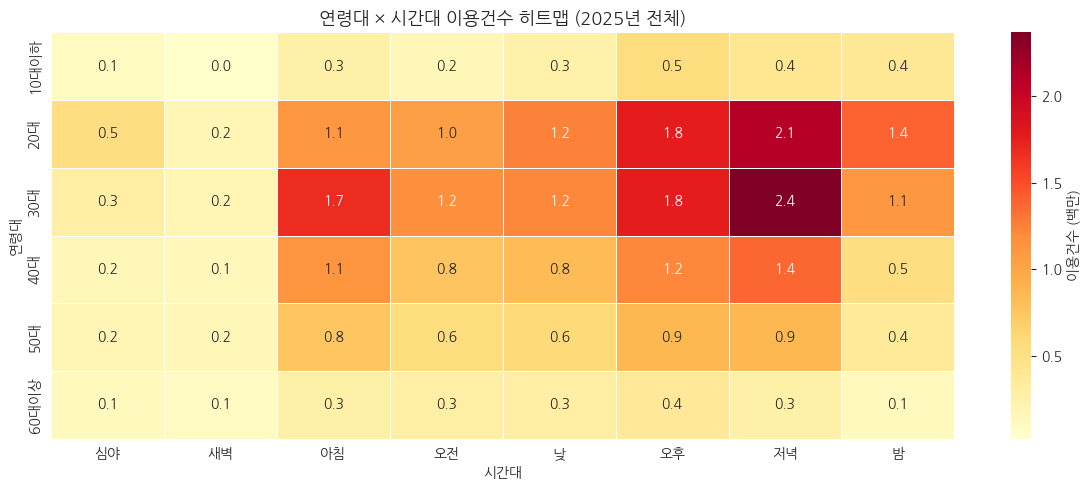

In [ ]:
heatmap_data = (
    df_basic.groupby(['연령대', '시간대'], observed=True)['이용건수']
    .sum()
    .unstack()
    .reindex(AGE_ORDER)
    [TIME_ORDER]
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data / 1e6,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '이용건수 (백만)'}
)
ax.set_title('연령대 × 시간대 이용건수 히트맵 (2025년 전체)', fontsize=13)
ax.set_xlabel('시간대')
ax.set_ylabel('연령대')
plt.tight_layout()
plt.show()

[연령대와 시간대의 교차 분석을 통해 이용 집중 구간을 확인]
- 20대와 30대의 **저녁** 시간대 이용이 히트맵에서 가장 진한 색으로 나타난다.
- 그 외 **아침**, **오후**의 비중이 높은 것을 통해 출퇴근 이용이 집중됨을 확인했다.
- 10대 이하와 60대 이상은 전 시간대에 걸쳐 낮은 이용 밀도를 보인다.

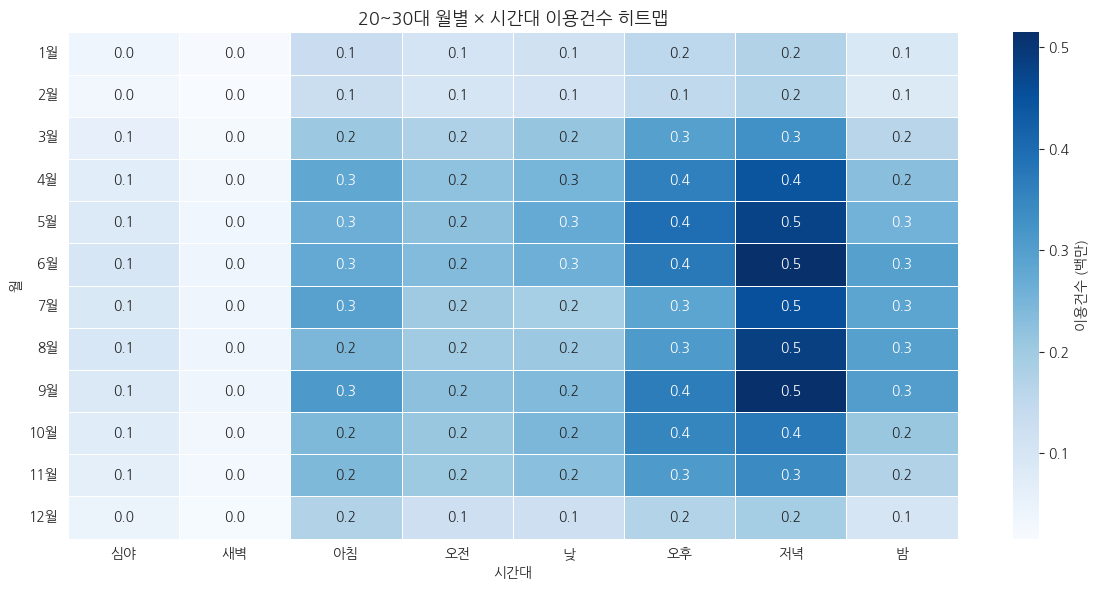

In [ ]:
heatmap_2030 = (
    df_2030.groupby(['대여월', '시간대'], observed=True)['이용건수']
    .sum()
    .unstack()
    [TIME_ORDER]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_2030 / 1e6,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '이용건수 (백만)'}
)
ax.set_title('20~30대 월별 × 시간대 이용건수 히트맵', fontsize=13)
ax.set_xlabel('시간대')
ax.set_ylabel('월')
ax.set_yticklabels([f'{m}월' for m in range(1, 13)], rotation=0)
plt.tight_layout()
plt.show()

[20대~30대의 월별·시간대 교차 패턴을 확인]
- **5월과 6월**, **저녁** 시간대 조합이 가장 높은 이용건수를 기록한다.
- 출퇴근 피크 패턴은 연중 지속되나, **5월과 6월, 9월** 에 특히 두드러진다.
- 겨울철(12~2월)에는 대부분의 시간대에 걸쳐 이용건수가 감소한다.

### 4-8. 속도 분석

평균 속도(km/h) 통한 이용 특성을 파악    
속도는 이동거리 ÷ 이용시간으로 산출하며, IQR 이상치 제거 후 집계된 결과값

In [ ]:
def weighted_speed(df):
    return (df['평균_속도_kmh'] * df['이용건수']).sum() / df['이용건수'].sum() # 각 그룹의 속도에 이용건수만큼의 가중치 부여

total_speed = weighted_speed(df_basic)
speed_2030  = weighted_speed(df_2030)

print(f'2025년 전체 평균 속도:   {total_speed:.2f} km/h')
print(f'20~30대 평균 속도:       {speed_2030:.2f} km/h')

age_speed = df_basic.groupby('연령대', observed=True).apply(weighted_speed).reindex(AGE_ORDER)
print('\n=== 연령대별 평균 속도 ===')
for age, spd in age_speed.items():
    print(f'  {age}: {spd:.2f} km/h')

2025년 전체 평균 속도:   8.32 km/h
20~30대 평균 속도:       8.45 km/h

=== 연령대별 평균 속도 ===
  10대이하: 8.53 km/h
  20대: 8.48 km/h
  30대: 8.42 km/h
  40대: 8.19 km/h
  50대: 8.11 km/h
  60대이상: 7.58 km/h


### 4-9. 통합 CSV 저장

In [ ]:
out_path = f'{OUTPUT_DIR}/집계_기본_2025_전체.csv'
df_basic.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'저장 완료: {out_path}')

저장 완료: /content/drive/MyDrive/[코드잇] DA16 초급프로젝트_3팀/데이터/집계/집계_기본_2025_전체.csv


In [ ]:
!pip install openpyxl -q

In [ ]:
output_excel_path = f'{OUTPUT_DIR}/따릉이_연령대_거리구간_분포_정리.xlsx'

with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
    pivot_count.to_excel(writer, sheet_name='연령대별_거리구간_건수')
    pivot_rate.to_excel(writer, sheet_name='연령대별_거리구간_비율')
    distance_age_count.to_excel(writer, sheet_name='거리구간별_연령대_건수')
    distance_age_rate.to_excel(writer, sheet_name='거리구간별_연령대_비율')

print(f'Excel 저장 완료: {output_excel_path}')

## 5. 상세 이용 패턴 분석

월별 집계 데이터를 기반으로 연령대·거리구간·요일·평일/주말 기준의 상세 이용 패턴을 분석한다.
본 데이터는 연령대, 시간대, 요일, 주말여부, 거리구간 기준으로 집계되어 있으므로, 행 개수가 아닌 `이용건수`를 기준으로 집계한다.

In [ ]:
file_path = f'{OUTPUT_DIR}/집계_기본_2025_전체.csv'
print('분석 파일 경로:', file_path)

분석 파일 경로: /content/drive/MyDrive/[코드잇] DA16 초급프로젝트_3팀/데이터/집계/집계_기본_2025_전체.csv


### 데이터 불러오기

Section 4-10에서 저장한 통합 집계 CSV를 불러온다.
Section 4-1의 `df_basic`이 메모리에 있는 경우 아래 셀 대신 `df = df_basic.copy()`를 사용해도 된다.

In [ ]:
df = pd.read_csv(file_path, encoding='utf-8-sig')
print(f'로드 완료: {df.shape}')
df.head()

로드 완료: (20158, 12)


,대여월,연령대,시간대,대여요일,주말여부,거리구간,이용건수,평균_이용시간,중앙값_이용시간,평균_이용거리_km,중앙값_이용거리_km,평균_속도_kmh
0,1,10대이하,심야,0,False,1km미만,113,8.59,5.0,0.67,0.74,8.03
1,1,10대이하,심야,0,False,1~3km,263,14.45,12.0,1.80,1.73,9.05
2,1,10대이하,심야,0,False,3~5km,64,27.91,24.0,3.85,3.76,9.50
3,1,10대이하,심야,0,False,5~10km,43,53.12,44.0,6.65,6.40,8.83
4,1,10대이하,심야,0,False,10km이상,6,79.00,77.5,12.10,12.40,9.65


## 분석 기준 컬럼 정리

연령대와 거리구간의 표시 순서를 지정하고, 분석 기준이 되는 `이용건수` 컬럼을 숫자형으로 변환한다.

In [ ]:
# 분석에 사용할 순서 지정
age_order = ['10대이하', '20대', '30대', '40대', '50대', '60대이상']
distance_order = ['1km미만', '1~3km', '3~5km', '5~10km', '10km이상']

# 컬럼 정리
df.columns = df.columns.str.strip()
df['이용건수'] = pd.to_numeric(df['이용건수'], errors='coerce').fillna(0)

df['연령대'] = pd.Categorical(df['연령대'], categories=age_order, ordered=True)
df['거리구간'] = pd.Categorical(df['거리구간'], categories=distance_order, ordered=True)

# 연령대 x 거리구간별 이용건수 합계
age_distance = (
    df.groupby(['연령대', '거리구간'], observed=False)['이용건수']
      .sum()
      .reset_index()
)

pivot_count = (
    age_distance
    .pivot(index='연령대', columns='거리구간', values='이용건수')
    .reindex(index=age_order, columns=distance_order)
    .fillna(0)
)

# 연령대별 거리구간 비율
pivot_rate = pivot_count.div(pivot_count.sum(axis=1), axis=0) * 100

display(pivot_count.style.format('{:,.0f}'))
display(pivot_rate.style.format('{:.1f}%'))

거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
연령대,,,,,
10대이하,"762,447","1,038,119","193,263","115,870","40,504"
20대,"3,366,548","4,228,722","905,814","635,198","238,947"
30대,"3,583,210","4,336,353","959,240","665,290","251,156"
40대,"2,069,983","2,678,884","704,521","515,004","195,847"
50대,"1,351,875","1,910,395","536,702","381,884","148,493"
60대이상,"576,685","821,735","228,600","160,130","63,051"


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
연령대,,,,,
10대이하,35.5%,48.3%,9.0%,5.4%,1.9%
20대,35.9%,45.1%,9.7%,6.8%,2.5%
30대,36.6%,44.3%,9.8%,6.8%,2.6%
40대,33.6%,43.5%,11.4%,8.4%,3.2%
50대,31.2%,44.1%,12.4%,8.8%,3.4%
60대이상,31.2%,44.4%,12.4%,8.7%,3.4%


### 5. 연령대별 거리구간 이용건수 집계

연령대와 거리구간별로 `이용건수`를 합산하여 이용 분포를 확인한다.  
집계 데이터이므로 단순 행 개수가 아니라 `이용건수`의 합계를 사용한다.

In [ ]:
# 분석에 사용할 순서 지정
age_order = ['10대이하', '20대', '30대', '40대', '50대', '60대이상']
distance_order = ['1km미만', '1~3km', '3~5km', '5~10km', '10km이상']

# 컬럼 정리
df.columns = df.columns.str.strip()
df['이용건수'] = pd.to_numeric(df['이용건수'], errors='coerce').fillna(0)

df['연령대'] = pd.Categorical(df['연령대'], categories=age_order, ordered=True)
df['거리구간'] = pd.Categorical(df['거리구간'], categories=distance_order, ordered=True)

# 연령대 x 거리구간별 이용건수 합계
age_distance = (
    df.groupby(['연령대', '거리구간'], observed=False)['이용건수']
      .sum()
      .reset_index()
)

pivot_count = (
    age_distance
    .pivot(index='연령대', columns='거리구간', values='이용건수')
    .reindex(index=age_order, columns=distance_order)
    .fillna(0)
)

# 연령대별 거리구간 비율
pivot_rate = pivot_count.div(pivot_count.sum(axis=1), axis=0) * 100

display(pivot_count.style.format('{:,.0f}'))
display(pivot_rate.style.format('{:.1f}%'))

거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
연령대,,,,,
10대이하,"762,447","1,038,119","193,263","115,870","40,504"
20대,"3,366,548","4,228,722","905,814","635,198","238,947"
30대,"3,583,210","4,336,353","959,240","665,290","251,156"
40대,"2,069,983","2,678,884","704,521","515,004","195,847"
50대,"1,351,875","1,910,395","536,702","381,884","148,493"
60대이상,"576,685","821,735","228,600","160,130","63,051"


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
연령대,,,,,
10대이하,35.5%,48.3%,9.0%,5.4%,1.9%
20대,35.9%,45.1%,9.7%,6.8%,2.5%
30대,36.6%,44.3%,9.8%,6.8%,2.6%
40대,33.6%,43.5%,11.4%,8.4%,3.2%
50대,31.2%,44.1%,12.4%,8.8%,3.4%
60대이상,31.2%,44.4%,12.4%,8.7%,3.4%


#### 연령대별 거리구간 이용 비율 히트맵
히트맵을 활용하여 연령대와 거리구간 조합별 이용 비율을 직관적으로 확인한다.
색이 진할수록 해당 연령대에서 해당 거리구간의 이용 비중이 높다는 의미이다.

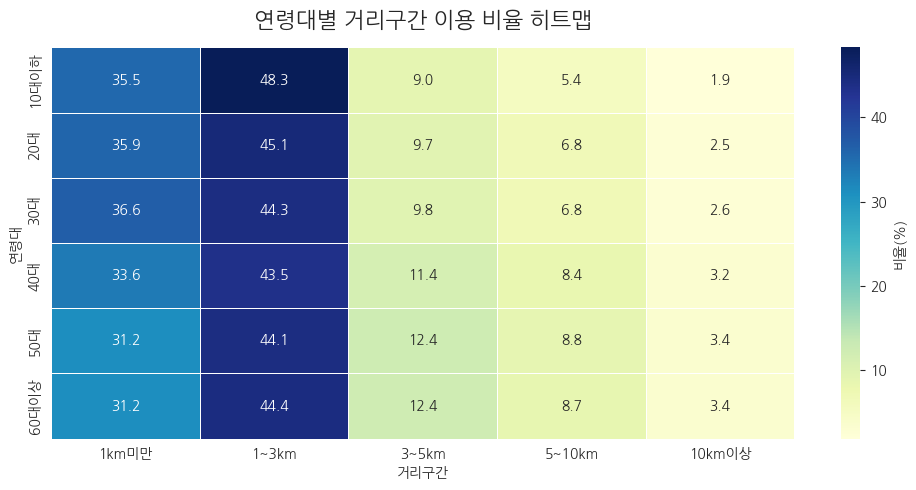

In [ ]:
# 시각화: 연령대별 거리구간 비율 - 히트맵
plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot_rate,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': '비율(%)'}
)

plt.title('연령대별 거리구간 이용 비율 히트맵', fontsize=16, pad=15)
plt.xlabel('거리구간')
plt.ylabel('연령대')
plt.tight_layout()
plt.show()

[연령대별 거리구간 이용 비율 확인]

- 모든 연령대에서 1 ~ 3km 구간의 이용 비율이 가장 높게 나타났고, 그 다음으로는 1km 미만 구간의 이용 비율이 높게 나타났다.
- 주요 분석 대상인 2030에서도 3km 미만 구간의 이용 비율이 각각 81%, 80.9%로 높아 따릉이가 주로 단거리 이동수단으로 활용되고 있음을 확인했다.
- 반면 3km 이상 구간부터는 이용 비율이 크게 낮아지며 10km 이상 장거리 이용은 모든 연령대에서 낮은 비중을 차지하고 있다.

#### 거리구간별 연령대 분포 분석

이번에는 거리구간을 기준으로 각 거리구간 안에서 연령대별 이용 비중이 어떻게 나타나는지 확인한다.  
기존의 연령대별 거리구간 분포와 반대로, 각 거리구간별 전체 이용건수 대비 연령대별 비율을 계산한다.

In [ ]:
# 분석 기준 순서 지정
age_order = ['10대이하', '20대', '30대', '40대', '50대', '60대이상']
distance_order = ['1km미만', '1~3km', '3~5km', '5~10km', '10km이상']

# 컬럼 정리
df.columns = df.columns.str.strip()

df['연령대'] = df['연령대'].astype(str).str.strip()
df['거리구간'] = df['거리구간'].astype(str).str.strip()

# 혹시 '10km 이상'처럼 띄어쓰기 있는 값이 있으면 통일
df['거리구간'] = df['거리구간'].replace({
    '10km 이상': '10km이상'
})

df['이용건수'] = pd.to_numeric(df['이용건수'], errors='coerce').fillna(0)

df['연령대'] = pd.Categorical(df['연령대'], categories=age_order, ordered=True)
df['거리구간'] = pd.Categorical(df['거리구간'], categories=distance_order, ordered=True)

In [ ]:
# 연령대 x 거리구간 이용건수 집계
age_distance_count = (
    df.groupby(['연령대', '거리구간'], observed=False)['이용건수']
      .sum()
      .reset_index()
      .pivot(index='연령대', columns='거리구간', values='이용건수')
      .reindex(index=age_order, columns=distance_order)
      .fillna(0)
)

# 1. 연령대별 거리구간 비율
# 각 연령대 안에서 거리구간별 비율
age_distance_rate = (
    age_distance_count
    .div(age_distance_count.sum(axis=1), axis=0)
    * 100
)

# 2. 거리구간별 연령대 비율
# 각 거리구간 안에서 연령대별 비율
distance_age_count = age_distance_count.T

distance_age_rate = (
    distance_age_count
    .div(distance_age_count.sum(axis=1), axis=0)
    * 100
)

print('연령대별 거리구간 이용건수')
display(age_distance_count.style.format('{:,.0f}'))

print('연령대별 거리구간 이용 비율')
display(age_distance_rate.style.format('{:.1f}%'))

print('거리구간별 연령대 이용건수')
display(distance_age_count.style.format('{:,.0f}'))

print('거리구간별 연령대 이용 비율')
display(distance_age_rate.style.format('{:.1f}%'))

연령대별 거리구간 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
연령대,,,,,
10대이하,"762,447","1,038,119","193,263","115,870","40,504"
20대,"3,366,548","4,228,722","905,814","635,198","238,947"
30대,"3,583,210","4,336,353","959,240","665,290","251,156"
40대,"2,069,983","2,678,884","704,521","515,004","195,847"
50대,"1,351,875","1,910,395","536,702","381,884","148,493"
60대이상,"576,685","821,735","228,600","160,130","63,051"


연령대별 거리구간 이용 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
연령대,,,,,
10대이하,35.5%,48.3%,9.0%,5.4%,1.9%
20대,35.9%,45.1%,9.7%,6.8%,2.5%
30대,36.6%,44.3%,9.8%,6.8%,2.6%
40대,33.6%,43.5%,11.4%,8.4%,3.2%
50대,31.2%,44.1%,12.4%,8.8%,3.4%
60대이상,31.2%,44.4%,12.4%,8.7%,3.4%


거리구간별 연령대 이용건수


연령대,10대이하,20대,30대,40대,50대,60대이상
거리구간,,,,,,
1km미만,"762,447","3,366,548","3,583,210","2,069,983","1,351,875","576,685"
1~3km,"1,038,119","4,228,722","4,336,353","2,678,884","1,910,395","821,735"
3~5km,"193,263","905,814","959,240","704,521","536,702","228,600"
5~10km,"115,870","635,198","665,290","515,004","381,884","160,130"
10km이상,"40,504","238,947","251,156","195,847","148,493","63,051"


거리구간별 연령대 이용 비율


연령대,10대이하,20대,30대,40대,50대,60대이상
거리구간,,,,,,
1km미만,6.5%,28.7%,30.6%,17.7%,11.5%,4.9%
1~3km,6.9%,28.2%,28.9%,17.8%,12.7%,5.5%
3~5km,5.5%,25.7%,27.2%,20.0%,15.2%,6.5%
5~10km,4.7%,25.7%,26.9%,20.8%,15.4%,6.5%
10km이상,4.3%,25.5%,26.8%,20.9%,15.8%,6.7%


#### 거리구간별 연령대 이용 비율 히트맵

거리구간별로 어떤 연령대의 이용 비중이 높은지 히트맵으로 확인한다.  
색이 진할수록 해당 거리구간에서 해당 연령대의 이용 비율이 높다는 의미이다.

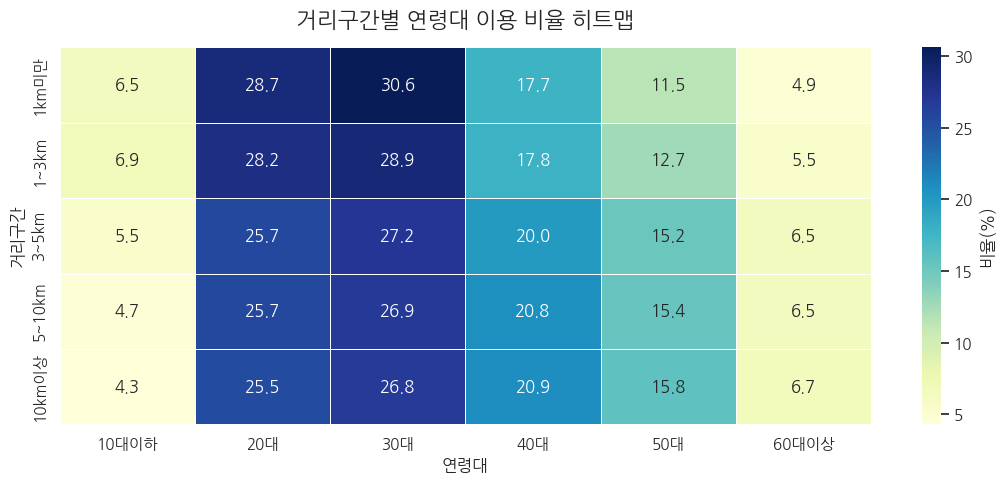

In [ ]:
# 거리구간별 연령대 비율 히트맵
plt.figure(figsize=(11, 5))

sns.heatmap(
    distance_age_rate,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': '비율(%)'}
)

plt.title('거리구간별 연령대 이용 비율 히트맵', fontsize=16, pad=15)
plt.xlabel('연령대')
plt.ylabel('거리구간')
plt.tight_layout()
plt.show()

[거리구간별 연령대 이용 비율 히트맵]


거리구간별 연령대 이용 비율 히트맵을 확인했다.
- 전체적인 이용 건수의 비중이 20대와 30대가 높기 때문에 해당 그래프에서도 동일한 특징이 나타난다.
- **1km미만** 단거리에서는 **30대**의 비중이 높은 반면 **1 ~ 3km**에서는 **20대**의 비중이 높게 나타나는 것이 특징이다.

### 요일별 거리구간별 이용분포 분석

2025년 따릉이 집계 데이터를 활용하여 요일별 거리구간 이용분포를 확인한다.  
요일은 기존 숫자값 `0~6`을 `월요일~일요일`로 변환하여 분석한다.

분석은 두 기준으로 나누어 진행한다.

- 전연령대 요일별 거리구간 이용분포
- 20~30대 요일별 거리구간 이용분포

#### 20~30대 데이터 필터링

전연령대 분석과 비교하기 위해 `연령대` 컬럼에서 `20대`와 `30대`만 추출한 데이터를 별도로 생성한다.

In [ ]:
# 요일별 거리구간별 이용분포 분석

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 순서 지정
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
distance_order = ['1km미만', '1~3km', '3~5km', '5~10km', '10km이상']

weekday_map = {
    0: '월요일',
    1: '화요일',
    2: '수요일',
    3: '목요일',
    4: '금요일',
    5: '토요일',
    6: '일요일'
}

# 컬럼 정리
df.columns = df.columns.str.strip()

df['이용건수'] = pd.to_numeric(df['이용건수'], errors='coerce').fillna(0)
df['대여요일'] = pd.to_numeric(df['대여요일'], errors='coerce')

df['요일명'] = df['대여요일'].map(weekday_map)

df['거리구간'] = df['거리구간'].astype(str).str.strip()
df['거리구간'] = df['거리구간'].replace({
    '10km 이상': '10km이상'
})

df['요일명'] = pd.Categorical(df['요일명'], categories=weekday_order, ordered=True)
df['거리구간'] = pd.Categorical(df['거리구간'], categories=distance_order, ordered=True)

# 20~30대 데이터 필터링
df_2030 = df[df['연령대'].isin(['20대', '30대'])].copy()

#### 요일별 거리구간 이용분포 집계 함수 생성

요일과 거리구간을 기준으로 `이용건수`를 합산하는 함수를 생성한다.  
이 함수는 이용건수 표와 요일별 거리구간 이용비율 표를 함께 반환한다.

집계 데이터이므로 단순 행 개수가 아니라 `이용건수` 합계를 기준으로 분석한다.

In [ ]:
# 요일별 거리구간 분포를 만드는 함수

def make_weekday_distance_table(data):
    count_table = (
        data.groupby(['요일명', '거리구간'], observed=False)['이용건수']
            .sum()
            .reset_index()
            .pivot(index='요일명', columns='거리구간', values='이용건수')
            .reindex(index=weekday_order, columns=distance_order)
            .fillna(0)
    )

    rate_table = count_table.div(count_table.sum(axis=1), axis=0) * 100

    return count_table, rate_table

#### 전연령대 요일별 거리구간 이용분포 계산

전체 연령대를 대상으로 요일별 거리구간 이용건수와 이용비율을 계산한다.  
이용비율은 각 요일 안에서 거리구간별 이용건수가 차지하는 비중을 의미한다.

In [ ]:
# 전연령대 요일별 거리구간 이용분포 계산
all_weekday_distance_count, all_weekday_distance_rate = make_weekday_distance_table(df)

#### 20~30대 요일별 거리구간 이용분포 계산

20대와 30대만 대상으로 요일별 거리구간 이용건수와 이용비율을 계산한다.  
이를 통해 전체 이용자와 20~30대 이용자의 거리 이용 패턴 차이를 비교할 수 있다.

In [ ]:
# 20~30대 요일별 거리구간 이용분포 계산
age2030_weekday_distance_count, age2030_weekday_distance_rate = make_weekday_distance_table(df_2030)

#### 요일별 거리구간 이용분포 표 확인

전연령대와 20~30대의 요일별 거리구간 이용건수 및 이용비율 표를 확인한다.

In [ ]:
# 표 확인

print('전연령대 요일별 거리구간 이용건수')
display(all_weekday_distance_count.style.format('{:,.0f}'))

print('전연령대 요일별 거리구간 이용비율')
display(all_weekday_distance_rate.style.format('{:.1f}%'))

print('20~30대 요일별 거리구간 이용건수')
display(age2030_weekday_distance_count.style.format('{:,.0f}'))

print('20~30대 요일별 거리구간 이용비율')
display(age2030_weekday_distance_rate.style.format('{:.1f}%'))

전연령대 요일별 거리구간 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일명,,,,,
월요일,"1,816,493","2,235,849","500,750","333,061","118,797"
화요일,"1,886,003","2,321,641","522,669","348,709","125,042"
수요일,"1,915,303","2,375,207","534,975","353,459","124,593"
목요일,"1,923,588","2,412,408","549,681","364,314","130,620"
금요일,"1,757,779","2,208,140","498,376","329,690","117,752"
토요일,"1,229,527","1,731,225","438,648","335,126","140,761"
일요일,"1,182,055","1,729,738","483,041","409,017","180,433"


전연령대 요일별 거리구간 이용비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일명,,,,,
월요일,36.3%,44.7%,10.0%,6.7%,2.4%
화요일,36.2%,44.6%,10.0%,6.7%,2.4%
수요일,36.1%,44.8%,10.1%,6.7%,2.3%
목요일,35.8%,44.8%,10.2%,6.8%,2.4%
금요일,35.8%,45.0%,10.1%,6.7%,2.4%
토요일,31.7%,44.7%,11.3%,8.6%,3.6%
일요일,29.7%,43.4%,12.1%,10.3%,4.5%


20~30대 요일별 거리구간 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일명,,,,,
월요일,"1,077,660","1,264,967","258,804","170,665","61,105"
화요일,"1,120,014","1,313,775","270,726","178,145","63,478"
수요일,"1,128,590","1,336,939","276,281","179,291","63,418"
목요일,"1,137,402","1,364,819","285,937","186,635","66,527"
금요일,"1,031,914","1,237,141","256,325","169,330","60,352"
토요일,"734,243","1,010,161","242,213","185,757","76,649"
일요일,"719,935","1,037,273","274,768","230,665","98,574"


20~30대 요일별 거리구간 이용비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일명,,,,,
월요일,38.0%,44.6%,9.1%,6.0%,2.2%
화요일,38.0%,44.6%,9.2%,6.0%,2.2%
수요일,37.8%,44.8%,9.3%,6.0%,2.1%
목요일,37.4%,44.9%,9.4%,6.1%,2.2%
금요일,37.5%,44.9%,9.3%,6.1%,2.2%
토요일,32.6%,44.9%,10.8%,8.3%,3.4%
일요일,30.5%,43.9%,11.6%,9.8%,4.2%


#### 전연령대 요일별 거리구간 이용비율 히트맵

전연령대 기준으로 각 요일의 거리구간별 이용비율을 히트맵으로 시각화한다.  
색이 진할수록 해당 요일에서 해당 거리구간의 이용 비중이 높다는 의미이다.

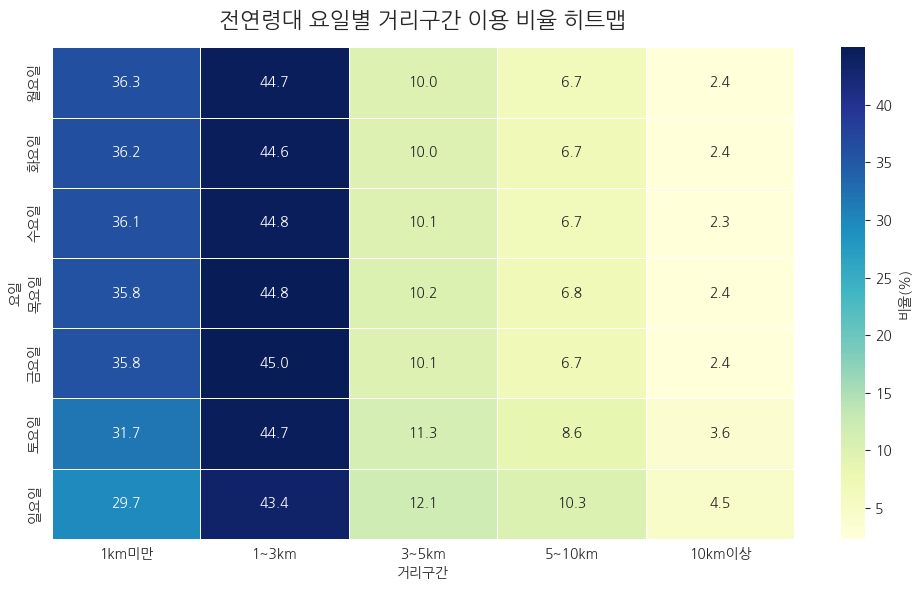

In [ ]:
# 전연령대 히트맵

plt.figure(figsize=(10, 6))

sns.heatmap(
    all_weekday_distance_rate,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': '비율(%)'}
)

plt.title('전연령대 요일별 거리구간 이용 비율 히트맵', fontsize=16, pad=15)
plt.xlabel('거리구간')
plt.ylabel('요일')
plt.tight_layout()
plt.show()

[전연령대 요일별 거리구간 이용 비율 히트맵]

전연령대 요일별 거리구간 이용 비율을 히트맵을 통해 확인했다.
- 요일과 상관 없이 가장 높은 비율의 이용 거리 구간은 **1~3km**이다.
- **평일**에 **초단거리(1km미만)** 이용 비율이 높으며, **주말**에는 **중장거리(3km이상)**의 비율이 소폭 상승한다.
- 평일 출퇴근을 위한 이용과 주말 여가 목적의 이용이 반영된 수치로 해석된다.

#### 20~30대 요일별 거리구간 이용비율 히트맵

2030대 기준으로 각 요일의 거리구간별 이용비율을 히트맵으로 시각화한다.
전연령대 결과와 비교하여 2030대의 요일별 거리 이용 패턴을 확인할 수 있다.

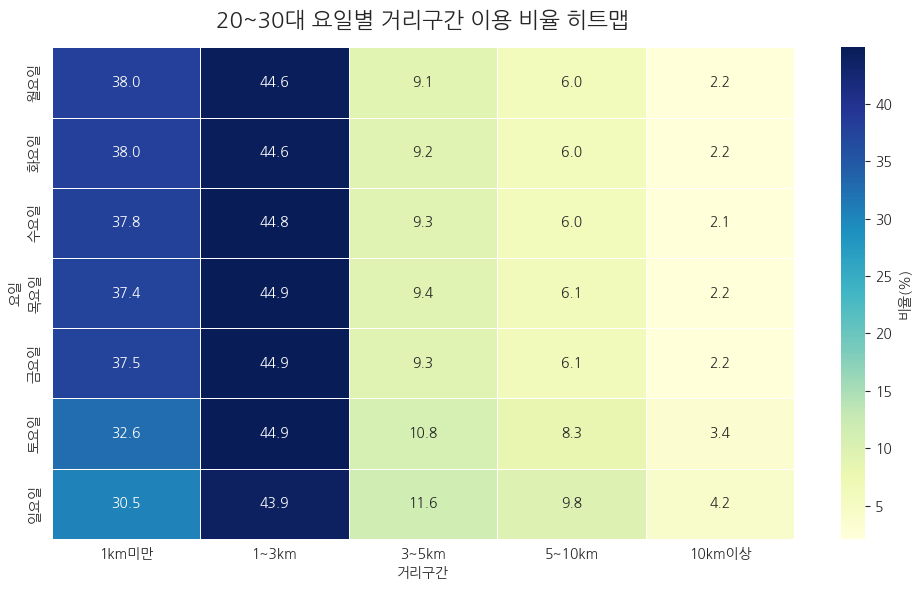

In [ ]:
# 20~30대 히트맵

plt.figure(figsize=(10, 6))

sns.heatmap(
    age2030_weekday_distance_rate,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': '비율(%)'}
)

plt.title('20~30대 요일별 거리구간 이용 비율 히트맵', fontsize=16, pad=15)
plt.xlabel('거리구간')
plt.ylabel('요일')
plt.tight_layout()
plt.show()

[20~30대 요일별 거리구간 이용 비율 히트맵}


전연령대의 요일별 거리구간과 함께 20~30대의 요일별 거리구간도 확인했다.
- 전체적인 분포는 전연령대의 히트맵과 유사하다
- 다만 수치상 **중장거리(3km이상)** 비율이 소폭 하락했다.

### 평일/주말 요일별 거리구간 이용분포 분석

2025년 따릉이 집계 데이터를 활용하여 평일과 주말의 요일별 거리구간 이용분포를 확인한다.

요일은 기존 숫자값 `0~6`을 `월요일~일요일`로 변환한다.  
이용건수 평균은 단순 평균이 아니라, 2025년 실제 달력에서 해당 요일이 등장한 일수를 기준으로 계산한다.

In [ ]:
# 한글 폰트 및 시각화 환경 설정
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import calendar

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font=font_name)

#### 요일명 변환 및 분석 기준 설정

`대여요일` 컬럼의 숫자값을 `월요일~일요일`로 변환한다.  
또한 거리구간은 분석 시 보기 쉽도록 짧은 거리에서 긴 거리 순서로 정렬한다.

In [ ]:
df_work = df.copy()
df_work.columns = df_work.columns.str.strip()

weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
distance_order = ['1km미만', '1~3km', '3~5km', '5~10km', '10km이상']

weekday_map = {
    0: '월요일',
    1: '화요일',
    2: '수요일',
    3: '목요일',
    4: '금요일',
    5: '토요일',
    6: '일요일'
}

df_work['대여월'] = pd.to_numeric(df_work['대여월'], errors='coerce')
df_work['대여요일'] = pd.to_numeric(df_work['대여요일'], errors='coerce')
df_work['이용건수'] = pd.to_numeric(df_work['이용건수'], errors='coerce').fillna(0)

df_work['요일명'] = df_work['대여요일'].map(weekday_map)
df_work['요일구분'] = np.where(df_work['대여요일'].isin([5, 6]), '주말', '평일')

df_work['거리구간'] = df_work['거리구간'].astype(str).str.strip()
df_work['거리구간'] = df_work['거리구간'].replace({'10km 이상': '10km이상'})

df_work['요일명'] = pd.Categorical(df_work['요일명'], categories=weekday_order, ordered=True)
df_work['거리구간'] = pd.Categorical(df_work['거리구간'], categories=distance_order, ordered=True)

#### 2025년 실제 요일별 날짜 수 계산

평균 이용건수를 정확히 계산하기 위해 2025년 각 월에 월요일, 화요일, 수요일 등이 각각 며칠 있었는지 계산한다.

In [ ]:
analysis_year = 2025

months = sorted(df_work['대여월'].dropna().astype(int).unique())

weekday_day_count_list = []

for month in months:
    last_day = calendar.monthrange(analysis_year, month)[1]
    dates = pd.date_range(
        start=f'{analysis_year}-{month:02d}-01',
        end=f'{analysis_year}-{month:02d}-{last_day}'
    )

    counts = dates.weekday.value_counts()

    for weekday_num in range(7):
        weekday_day_count_list.append({
            '대여월': month,
            '대여요일': weekday_num,
            '요일명': weekday_map[weekday_num],
            '요일구분': '주말' if weekday_num in [5, 6] else '평일',
            '해당월_요일일수': counts.get(weekday_num, 0)
        })

weekday_day_count = pd.DataFrame(weekday_day_count_list)

display(weekday_day_count.head())

,대여월,대여요일,요일명,요일구분,해당월_요일일수
0,1,0,월요일,평일,4
1,1,1,화요일,평일,4
2,1,2,수요일,평일,5
3,1,3,목요일,평일,5
4,1,4,금요일,평일,5


### 평일/주말별 거리구간 평균 이용건수 계산

월-금요일은 `평일`, 토~일요일은 `주말`로 구분한다.  
각 구분별 전체 이용건수를 실제 평일 일수와 주말 일수로 나누어 평균 이용건수를 계산한다.

In [ ]:
period_order = ['평일', '주말']

period_distance_total = (
    df_work
    .groupby(['요일구분', '거리구간'], observed=False)['이용건수']
    .sum()
    .reset_index()
)

period_total_days = (
    weekday_day_count
    .groupby('요일구분')['해당월_요일일수']
    .sum()
    .reset_index()
    .rename(columns={'해당월_요일일수': '해당구분_총일수'})
)

period_distance_avg = period_distance_total.merge(
    period_total_days,
    on='요일구분',
    how='left'
)

period_distance_avg['평균_일별_이용건수'] = (
    period_distance_avg['이용건수'] / period_distance_avg['해당구분_총일수']
)

period_distance_avg_table = (
    period_distance_avg
    .pivot(index='요일구분', columns='거리구간', values='평균_일별_이용건수')
    .reindex(index=period_order, columns=distance_order)
    .fillna(0)
)

period_distance_rate_table = (
    period_distance_avg_table
    .div(period_distance_avg_table.sum(axis=1), axis=0)
    * 100
)

display(period_distance_avg_table.style.format('{:,.1f}'))
display(period_distance_rate_table.style.format('{:.1f}%'))

거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일구분,,,,,
평일,"35,629.0","44,265.3","9,986.4","6,625.4","2,363.2"
주말,"23,188.3","33,278.5","8,862.4","7,155.2","3,088.4"


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일구분,,,,,
평일,36.0%,44.8%,10.1%,6.7%,2.4%
주말,30.7%,44.0%,11.7%,9.5%,4.1%


#### 평일/주말별 거리구간 평균 이용건수 비율 히트맵

평일과 주말 각각에서 거리구간별 평균 이용건수가 차지하는 비율을 히트맵으로 비교한다.  
색이 진할수록 해당 구분에서 해당 거리구간의 평균 이용건수 비중이 높다는 의미이다.

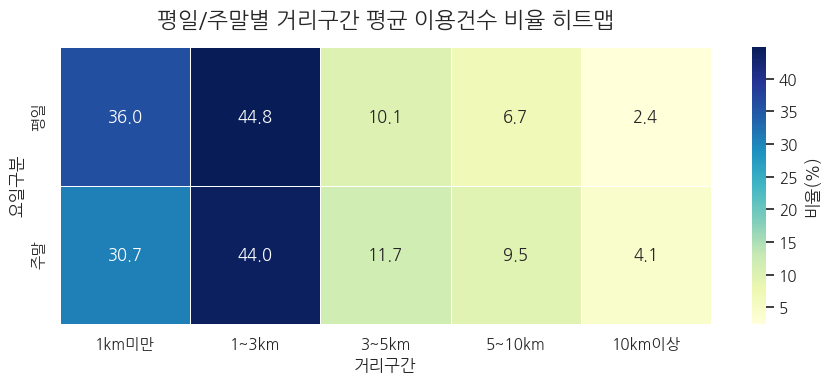

In [ ]:
plt.figure(figsize=(9, 4))

sns.heatmap(
    period_distance_rate_table,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': '비율(%)'}
)

plt.title('평일/주말별 거리구간 평균 이용건수 비율 히트맵', fontsize=16, pad=15)
plt.xlabel('거리구간')
plt.ylabel('요일구분')
plt.tight_layout()
plt.show()

[평일/주말별 거리구간 평균 이용건수 비율 히트맵]

평일/주말별 거리구간에 따른 평균 이용건수를 확인했다.
- **평일**에는 **1km미만**의 비중이 주말에 비해 유의미하게 높다.
- **주말**에는 상대적으로 **3km 이상** 거리구간의 비율이 높은 것으로 확인되었다.

#### 20~30대 평일/주말 평균 이용건수별 거리구간 이용분포 분석

이번에는 전체 연령대가 아니라 `20대`와 `30대`만 대상으로 평일/주말 평균 이용건수별 거리구간 이용분포를 확인한다.  
표에서는 평균 이용건수와 비율을 함께 확인하고, 시각화는 거리구간별 비율(%) 기준으로 나타낸다.

In [ ]:
# 20~30대 데이터 필터링
df_work_2030 = df_work[df_work['연령대'].isin(['20대', '30대'])].copy()

print('20~30대 데이터 크기:', df_work_2030.shape)
display(df_work_2030.head())

20~30대 데이터 크기: (6720, 14)


,대여월,연령대,시간대,대여요일,주말여부,거리구간,이용건수,평균_이용시간,중앙값_이용시간,평균_이용거리_km,중앙값_이용거리_km,평균_속도_kmh,요일명,요일구분
280,1,20대,심야,0,False,1km미만,750,6.31,5.0,0.69,0.72,8.93,월요일,평일
281,1,20대,심야,0,False,1~3km,1515,12.87,10.0,1.74,1.63,9.67,월요일,평일
282,1,20대,심야,0,False,3~5km,367,26.26,23.0,3.80,3.69,9.75,월요일,평일
283,1,20대,심야,0,False,5~10km,150,46.14,38.0,6.68,6.10,10.05,월요일,평일
284,1,20대,심야,0,False,10km이상,34,70.09,61.0,12.77,11.79,11.66,월요일,평일


#### 20~30대 요일별 거리구간 평균 이용건수 계산

20대와 30대만 대상으로 월요일부터 일요일까지 요일별 거리구간 이용건수를 합산한다.  
이후 2025년 실제 요일별 일수로 나누어 요일별 1일 평균 이용건수를 계산한다.

In [ ]:
# 20~30대 요일별 거리구간 이용건수 합계
weekday_distance_total_2030 = (
    df_work_2030
    .groupby(['대여요일', '거리구간'], observed=False)['이용건수']
    .sum()
    .reset_index()
)

# 요일별 실제 일수
weekday_total_days = (
    weekday_day_count
    .groupby('대여요일')['해당월_요일일수']
    .sum()
    .reset_index()
    .rename(columns={'해당월_요일일수': '해당요일_총일수'})
)

# 이용건수 합계와 요일별 일수 결합
weekday_distance_avg_2030 = weekday_distance_total_2030.merge(
    weekday_total_days,
    on='대여요일',
    how='left'
)

# 요일별 1일 평균 이용건수 계산
weekday_distance_avg_2030['평균_일별_이용건수'] = (
    weekday_distance_avg_2030['이용건수'] / weekday_distance_avg_2030['해당요일_총일수']
)

weekday_distance_avg_2030['요일명'] = weekday_distance_avg_2030['대여요일'].map(weekday_map)

# 평균 이용건수 표
weekday_distance_avg_table_2030 = (
    weekday_distance_avg_2030
    .pivot(index='요일명', columns='거리구간', values='평균_일별_이용건수')
    .reindex(index=weekday_order, columns=distance_order)
    .fillna(0)
)

# 요일별 거리구간 비율표
weekday_distance_rate_table_2030 = (
    weekday_distance_avg_table_2030
    .div(weekday_distance_avg_table_2030.sum(axis=1), axis=0)
    * 100
)

print('20~30대 요일별 거리구간 평균 이용건수')
display(weekday_distance_avg_table_2030.style.format('{:,.1f}'))

print('20~30대 요일별 거리구간 평균 이용건수 비율')
display(weekday_distance_rate_table_2030.style.format('{:.1f}%'))

20~30대 요일별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일명,,,,,
월요일,"20,724.2","24,326.3","4,977.0","3,282.0","1,175.1"
화요일,"21,538.7","25,264.9","5,206.3","3,425.9","1,220.7"
수요일,"21,294.2","25,225.3","5,212.8","3,382.8","1,196.6"
목요일,"21,873.1","26,246.5","5,498.8","3,589.1","1,279.4"
금요일,"19,844.5","23,791.2","4,929.3","3,256.3","1,160.6"
토요일,"14,120.1","19,426.2","4,657.9","3,572.2","1,474.0"
일요일,"13,844.9","19,947.6","5,284.0","4,435.9","1,895.7"


20~30대 요일별 거리구간 평균 이용건수 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일명,,,,,
월요일,38.0%,44.6%,9.1%,6.0%,2.2%
화요일,38.0%,44.6%,9.2%,6.0%,2.2%
수요일,37.8%,44.8%,9.3%,6.0%,2.1%
목요일,37.4%,44.9%,9.4%,6.1%,2.2%
금요일,37.5%,44.9%,9.3%,6.1%,2.2%
토요일,32.6%,44.9%,10.8%,8.3%,3.4%
일요일,30.5%,43.9%,11.6%,9.8%,4.2%


#### 20~30대 평일/주말별 거리구간 평균 이용건수 계산

20-30대 데이터를 기준으로 월-금요일은 `평일`, 토~일요일은 `주말`로 구분한다.  
각 구분별 전체 이용건수를 실제 평일 일수와 주말 일수로 나누어 평균 이용건수를 계산한다.

In [ ]:
# 20~30대 평일/주말별 거리구간 이용건수 합계
period_distance_total_2030 = (
    df_work_2030
    .groupby(['요일구분', '거리구간'], observed=False)['이용건수']
    .sum()
    .reset_index()
)

# 평일/주말별 실제 일수
period_total_days = (
    weekday_day_count
    .groupby('요일구분')['해당월_요일일수']
    .sum()
    .reset_index()
    .rename(columns={'해당월_요일일수': '해당구분_총일수'})
)

# 이용건수 합계와 평일/주말 일수 결합
period_distance_avg_2030 = period_distance_total_2030.merge(
    period_total_days,
    on='요일구분',
    how='left'
)

# 평일/주말별 1일 평균 이용건수 계산
period_distance_avg_2030['평균_일별_이용건수'] = (
    period_distance_avg_2030['이용건수'] / period_distance_avg_2030['해당구분_총일수']
)

# 평균 이용건수 표
period_distance_avg_table_2030 = (
    period_distance_avg_2030
    .pivot(index='요일구분', columns='거리구간', values='평균_일별_이용건수')
    .reindex(index=period_order, columns=distance_order)
    .fillna(0)
)

# 평일/주말별 거리구간 비율표
period_distance_rate_table_2030 = (
    period_distance_avg_table_2030
    .div(period_distance_avg_table_2030.sum(axis=1), axis=0)
    * 100
)

print('20~30대 평일/주말별 거리구간 평균 이용건수')
display(period_distance_avg_table_2030.style.format('{:,.1f}'))

print('20~30대 평일/주말별 거리구간 평균 이용건수 비율')
display(period_distance_rate_table_2030.style.format('{:.1f}%'))

20~30대 평일/주말별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일구분,,,,,
평일,"21,055.9","24,971.8","5,165.0","3,387.2","1,206.4"
주말,"13,982.5","19,686.9","4,971.0","4,004.1","1,684.8"


20~30대 평일/주말별 거리구간 평균 이용건수 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
요일구분,,,,,
평일,37.7%,44.8%,9.3%,6.1%,2.2%
주말,31.5%,44.4%,11.2%,9.0%,3.8%


#### 20~30대 평일/주말별 거리구간 평균 이용건수 비율 히트맵

20~30대의 평일과 주말 각각에서 거리구간별 평균 이용건수가 차지하는 비율을 히트맵으로 비교한다.

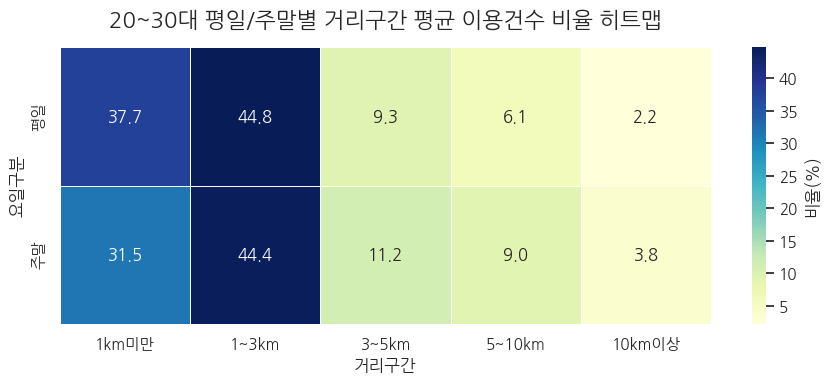

In [ ]:
plt.figure(figsize=(9, 4))

sns.heatmap(
    period_distance_rate_table_2030,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': '비율(%)'}
)

plt.title('20~30대 평일/주말별 거리구간 평균 이용건수 비율 히트맵', fontsize=16, pad=15)
plt.xlabel('거리구간')
plt.ylabel('요일구분')
plt.tight_layout()
plt.show()

[20~30대 평일/주말별 거리구간 평균 이용건수 비율 히트맵]

평일/주말별 거리구간에 따른 평균 이용건수를 20 ~ 30대에 한정하여 시각화했다.
- 전연령대와 동일하게 1~3km의 거리는 평일과 주말 모두 유사한 비율을 보이나, 1km미만의 초단거리에서는 유의미하게 차이가 나타난다.
- 20 ~ 30 대의 중장거리(3km이상) 비율이 낮았던 기존 데이터의 패턴이 위 그래프에서도 동일하게 관측된다.

### 전연령대, 20~30대 평일/주말 시간대별 거리구간 이용분포 분석

평일과 주말을 구분하여 시간대별 거리구간 이용분포를 확인한다.  
이용건수는 단순 합계가 아니라, 2025년 실제 요일별 일수를 기준으로 계산한 요일별 평균 이용건수를 사용한다.

분석 대상은 다음 세 그룹이다.

- 전연령대
- 20~30대

#### 시간대 및 분석 기준 설정

시간대는 `심야`, `새벽`, `아침`, `오전`, `낮`, `오후`, `저녁`, `밤` 순서로 정렬한다.  
거리구간은 짧은 거리에서 긴 거리 순서로 정렬한다.

In [ ]:
# 분석 기준 순서 설정
time_order = ['심야', '새벽', '아침', '오전', '낮', '오후', '저녁', '밤']
distance_order = ['1km미만', '1~3km', '3~5km', '5~10km', '10km이상']
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']

weekday_map = {
    0: '월요일',
    1: '화요일',
    2: '수요일',
    3: '목요일',
    4: '금요일',
    5: '토요일',
    6: '일요일'
}

# 기존 df를 복사해서 사용
df_time = df.copy()
df_time.columns = df_time.columns.str.strip()

df_time['대여월'] = pd.to_numeric(df_time['대여월'], errors='coerce')
df_time['대여요일'] = pd.to_numeric(df_time['대여요일'], errors='coerce')
df_time['이용건수'] = pd.to_numeric(df_time['이용건수'], errors='coerce').fillna(0)

df_time['요일명'] = df_time['대여요일'].map(weekday_map)
df_time['요일구분'] = np.where(df_time['대여요일'].isin([5, 6]), '주말', '평일')

df_time['시간대'] = df_time['시간대'].astype(str).str.strip()
df_time['거리구간'] = df_time['거리구간'].astype(str).str.strip()
df_time['거리구간'] = df_time['거리구간'].replace({'10km 이상': '10km이상'})

df_time['시간대'] = pd.Categorical(df_time['시간대'], categories=time_order, ordered=True)
df_time['거리구간'] = pd.Categorical(df_time['거리구간'], categories=distance_order, ordered=True)
df_time['요일명'] = pd.Categorical(df_time['요일명'], categories=weekday_order, ordered=True)

#### 2025년 실제 요일별 일수 계산

요일별 평균 이용건수를 계산하기 위해 2025년에 월요일, 화요일, 수요일 등이 각각 며칠 있었는지 계산한다.

In [ ]:
import calendar

analysis_year = 2025
months = sorted(df_time['대여월'].dropna().astype(int).unique())

weekday_day_count_list = []

for month in months:
    last_day = calendar.monthrange(analysis_year, month)[1]
    dates = pd.date_range(
        start=f'{analysis_year}-{month:02d}-01',
        end=f'{analysis_year}-{month:02d}-{last_day}'
    )

    counts = dates.weekday.value_counts()

    for weekday_num in range(7):
        weekday_day_count_list.append({
            '대여요일': weekday_num,
            '요일명': weekday_map[weekday_num],
            '요일구분': '주말' if weekday_num in [5, 6] else '평일',
            '해당요일_총일수': counts.get(weekday_num, 0)
        })

weekday_total_days = (
    pd.DataFrame(weekday_day_count_list)
    .groupby(['대여요일', '요일명', '요일구분'], as_index=False)['해당요일_총일수']
    .sum()
)

display(weekday_total_days)

,대여요일,요일명,요일구분,해당요일_총일수
0,0,월요일,평일,52
1,1,화요일,평일,52
2,2,수요일,평일,53
3,3,목요일,평일,52
4,4,금요일,평일,52
5,5,토요일,주말,52
6,6,일요일,주말,52


#### 시간대별 거리구간 평균 이용건수 계산 함수 생성

연령대 그룹과 평일/주말 구분을 입력하면, 시간대별 거리구간 평균 이용건수 표와 비율표를 생성하는 함수를 만든다.  
비율표는 각 시간대 안에서 거리구간별 평균 이용건수가 차지하는 비중을 의미한다.

In [ ]:
def make_time_distance_tables(data, period_name):
    temp = data[data['요일구분'] == period_name].copy()

    # 요일별, 시간대별, 거리구간별 이용건수 합계
    weekday_time_distance_total = (
        temp
        .groupby(['대여요일', '시간대', '거리구간'], observed=False)['이용건수']
        .sum()
        .reset_index()
    )

    # 요일별 실제 일수 결합
    weekday_time_distance_avg = weekday_time_distance_total.merge(
        weekday_total_days[['대여요일', '해당요일_총일수']],
        on='대여요일',
        how='left'
    )

    # 요일별 1일 평균 이용건수
    weekday_time_distance_avg['평균_일별_이용건수'] = (
        weekday_time_distance_avg['이용건수'] /
        weekday_time_distance_avg['해당요일_총일수']
    )

    # 평일이면 월~금의 요일별 평균을 합산, 주말이면 토~일의 요일별 평균을 합산
    time_distance_avg = (
        weekday_time_distance_avg
        .groupby(['시간대', '거리구간'], observed=False)['평균_일별_이용건수']
        .sum()
        .reset_index()
    )

    avg_table = (
        time_distance_avg
        .pivot(index='시간대', columns='거리구간', values='평균_일별_이용건수')
        .reindex(index=time_order, columns=distance_order)
        .fillna(0)
    )

    rate_table = avg_table.div(avg_table.sum(axis=1), axis=0) * 100

    return avg_table, rate_table

#### 전연령대 평일/주말 시간대별 거리구간 이용분포 계산

전연령대를 기준으로 평일과 주말의 시간대별 거리구간 평균 이용건수 및 비율을 계산한다.

In [ ]:
all_weekday_time_distance_avg, all_weekday_time_distance_rate = make_time_distance_tables(df_time, '평일')
all_weekend_time_distance_avg, all_weekend_time_distance_rate = make_time_distance_tables(df_time, '주말')

print('전연령대 평일 시간대별 거리구간 평균 이용건수')
display(all_weekday_time_distance_avg.style.format('{:,.1f}'))

print('전연령대 평일 시간대별 거리구간 비율')
display(all_weekday_time_distance_rate.style.format('{:.1f}%'))

print('전연령대 주말 시간대별 거리구간 평균 이용건수')
display(all_weekend_time_distance_avg.style.format('{:,.1f}'))

print('전연령대 주말 시간대별 거리구간 비율')
display(all_weekend_time_distance_rate.style.format('{:.1f}%'))

전연령대 평일 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,"5,497.7","8,748.4","2,197.5","1,301.4",353.4
새벽,"3,829.6","5,267.8","1,262.6",761.5,254.3
아침,"39,907.1","38,306.6","7,266.1","3,933.2",978.8
오전,"22,302.0","25,230.4","4,935.5","2,686.6",856.9
낮,"19,788.1","26,511.4","5,926.4","3,529.2","1,213.9"
오후,"30,506.2","41,385.4","10,112.4","7,100.4","2,655.3"
저녁,"37,177.4","50,463.7","12,340.9","9,358.8","3,822.7"
밤,"19,127.0","25,402.4","5,888.5","4,455.1","1,681.2"


전연령대 평일 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,30.4%,48.3%,12.1%,7.2%,2.0%
새벽,33.7%,46.3%,11.1%,6.7%,2.2%
아침,44.1%,42.4%,8.0%,4.4%,1.1%
오전,39.8%,45.0%,8.8%,4.8%,1.5%
낮,34.7%,46.5%,10.4%,6.2%,2.1%
오후,33.2%,45.1%,11.0%,7.7%,2.9%
저녁,32.9%,44.6%,10.9%,8.3%,3.4%
밤,33.8%,44.9%,10.4%,7.9%,3.0%


전연령대 주말 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,"2,491.6","4,359.0","1,176.1",742.2,214.9
새벽,"1,120.6","1,772.3",451.1,259.7,89.6
아침,"3,483.4","4,110.0",949.1,665.5,340.8
오전,"7,289.3","9,121.0","2,024.3","1,451.8",651.0
낮,"8,896.0","12,433.2","3,229.8","2,550.6","1,123.3"
오후,"9,554.5","14,417.5","4,199.8","3,590.6","1,529.1"
저녁,"7,933.7","12,237.7","3,527.3","3,173.2","1,457.3"
밤,"5,607.5","8,106.4","2,167.2","1,877.0",770.8


전연령대 주말 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,27.7%,48.5%,13.1%,8.3%,2.4%
새벽,30.3%,48.0%,12.2%,7.0%,2.4%
아침,36.5%,43.0%,9.9%,7.0%,3.6%
오전,35.5%,44.4%,9.9%,7.1%,3.2%
낮,31.5%,44.0%,11.4%,9.0%,4.0%
오후,28.7%,43.3%,12.6%,10.8%,4.6%
저녁,28.0%,43.2%,12.5%,11.2%,5.1%
밤,30.3%,43.8%,11.7%,10.1%,4.2%


#### 전연령대 평일/주말 시간대별 거리구간 비율 시각화

전연령대의 평일과 주말 이용분포를 비율 기준 히트맵과 누적 막대그래프로 확인한다.

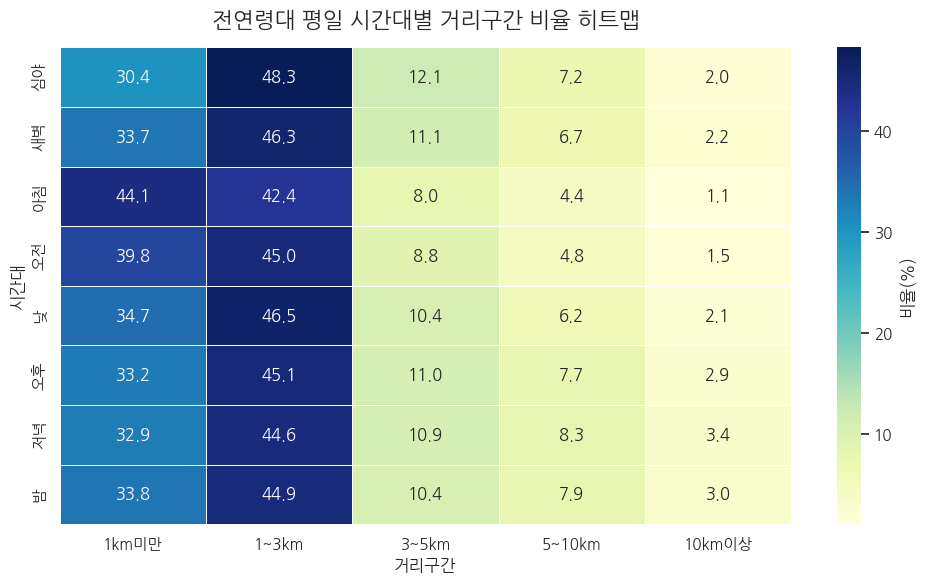

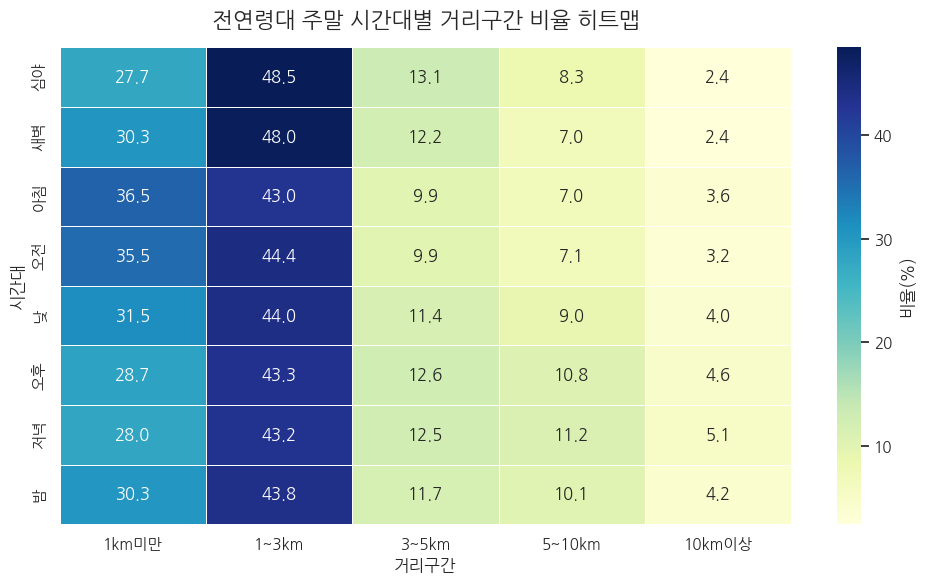

In [ ]:
def plot_time_distance_charts(rate_table, title_prefix):
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        rate_table,
        annot=True,
        fmt='.1f',
        cmap='YlGnBu',
        linewidths=0.5,
        cbar_kws={'label': '비율(%)'}
    )
    plt.title(f'{title_prefix} 시간대별 거리구간 비율 히트맵', fontsize=16, pad=15)
    plt.xlabel('거리구간')
    plt.ylabel('시간대')
    plt.tight_layout()
    plt.show()


plot_time_distance_charts(all_weekday_time_distance_rate, '전연령대 평일')
plot_time_distance_charts(all_weekend_time_distance_rate, '전연령대 주말')

[전연령대 평일 시간대별 거리구간 비율 히트맵]

평일 각 시간대별로 이용한 거리구간을 확인하기 위한 히트맵이다.
- **전 시간대**에서 **1km미만**, **1~3km**를 이용한 비율이 큰 것으로 관측된다.
- **아침**에는 1~3km에 비해 **1km미만**의 비율이 더 큰 것이 특징으로, 지하철역 혹은 버스정류장으로부터 목적지까지의 초단거리 이동을 목적으로 사용하는 것으로 추측된다.
- **1~3km**구간과 **3~5km** 구간은 다른 시간 대비 심야(0 ~ 3시)에 가장 높은 비율을 차지하는 특이점이 있다.


[전연령대 주말 시간대별 거리구간 비율 히트맵]

주말 각 시간대별로 이용한 거리구간을 확인하기 위한 히트맵이다.
- 전체적인 흐름은 평일과 비슷하게 **1km미만**과 **1~3km**의 비율이 높다
- 평일과 비교하여 **아침**에 **1km미만**의 비율이 **약 7%p** 하락한 것이 관측된다.
- 평일과 비교하여 **3km 이상** 비율이 소폭 상승했다.

#### 20~30대 평일/주말 시간대별 거리구간 이용분포 계산

20대와 30대만 대상으로 평일과 주말의 시간대별 거리구간 평균 이용건수 및 비율을 계산한다.

In [ ]:
df_time_2030 = df_time[df_time['연령대'].isin(['20대', '30대'])].copy()

age2030_weekday_time_distance_avg, age2030_weekday_time_distance_rate = make_time_distance_tables(df_time_2030, '평일')
age2030_weekend_time_distance_avg, age2030_weekend_time_distance_rate = make_time_distance_tables(df_time_2030, '주말')

print('20~30대 평일 시간대별 거리구간 평균 이용건수')
display(age2030_weekday_time_distance_avg.style.format('{:,.1f}'))

print('20~30대 평일 시간대별 거리구간 비율')
display(age2030_weekday_time_distance_rate.style.format('{:.1f}%'))

print('20~30대 주말 시간대별 거리구간 평균 이용건수')
display(age2030_weekend_time_distance_avg.style.format('{:,.1f}'))

print('20~30대 주말 시간대별 거리구간 비율')
display(age2030_weekend_time_distance_rate.style.format('{:.1f}%'))

20~30대 평일 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,"2,962.4","5,182.2","1,337.2",836.2,243.0
새벽,"1,802.8","2,383.6",500.0,275.4,83.8
아침,"23,769.9","20,446.5","2,989.3","1,268.5",263.9
오전,"13,820.9","13,806.0","2,267.4","1,097.7",304.9
낮,"11,512.7","14,463.6","2,873.9","1,643.2",541.3
오후,"16,776.0","21,896.0","5,042.9","3,436.3","1,239.8"
저녁,"22,881.6","30,751.0","7,067.5","5,390.9","2,193.6"
밤,"11,748.5","15,925.3","3,746.1","2,988.1","1,162.1"


20~30대 평일 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,28.1%,49.1%,12.7%,7.9%,2.3%
새벽,35.7%,47.2%,9.9%,5.5%,1.7%
아침,48.8%,42.0%,6.1%,2.6%,0.5%
오전,44.2%,44.1%,7.2%,3.5%,1.0%
낮,37.1%,46.6%,9.3%,5.3%,1.7%
오후,34.7%,45.2%,10.4%,7.1%,2.6%
저녁,33.5%,45.0%,10.4%,7.9%,3.2%
밤,33.0%,44.8%,10.5%,8.4%,3.3%


20~30대 주말 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,"1,415.2","2,742.9",765.7,509.0,151.1
새벽,550.1,919.9,223.1,130.3,38.1
아침,"1,994.7","2,112.9",377.6,221.2,101.1
오전,"4,422.8","5,167.4",989.2,633.4,261.2
낮,"5,409.8","7,233.8","1,708.5","1,285.8",543.6
오후,"5,724.0","8,410.0","2,320.1","1,985.4",823.7
저녁,"4,831.7","7,473.6","2,129.8","1,954.8",906.8
밤,"3,616.6","5,313.3","1,428.0","1,288.2",544.1


20~30대 주말 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,25.3%,49.1%,13.7%,9.1%,2.7%
새벽,29.6%,49.4%,12.0%,7.0%,2.0%
아침,41.5%,44.0%,7.9%,4.6%,2.1%
오전,38.5%,45.0%,8.6%,5.5%,2.3%
낮,33.4%,44.7%,10.6%,7.9%,3.4%
오후,29.7%,43.7%,12.0%,10.3%,4.3%
저녁,27.9%,43.2%,12.3%,11.3%,5.2%
밤,29.7%,43.6%,11.7%,10.6%,4.5%


#### 20~30대 평일/주말 시간대별 거리구간 비율 시각화

20~30대의 평일과 주말 이용분포를 비율 기준 히트맵과 누적 막대그래프로 확인한다.

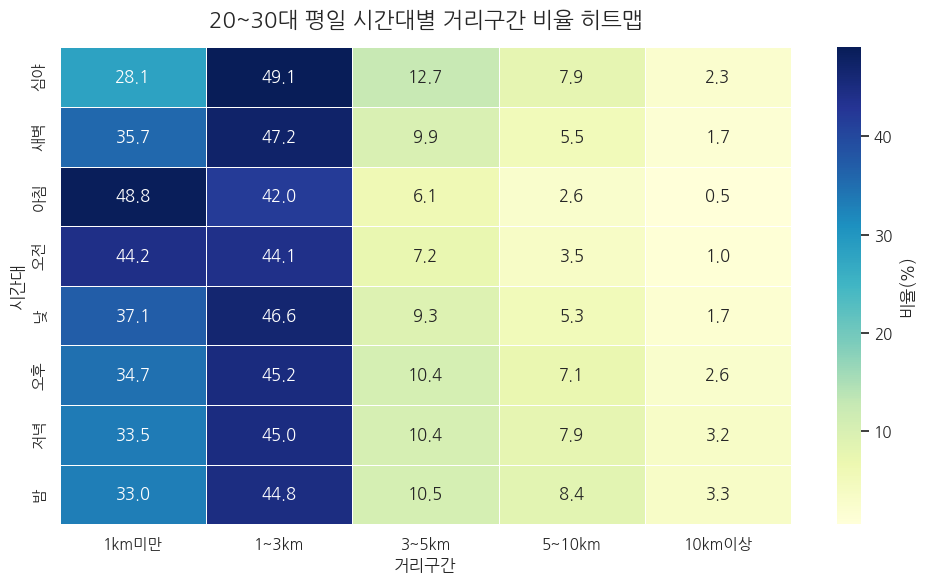

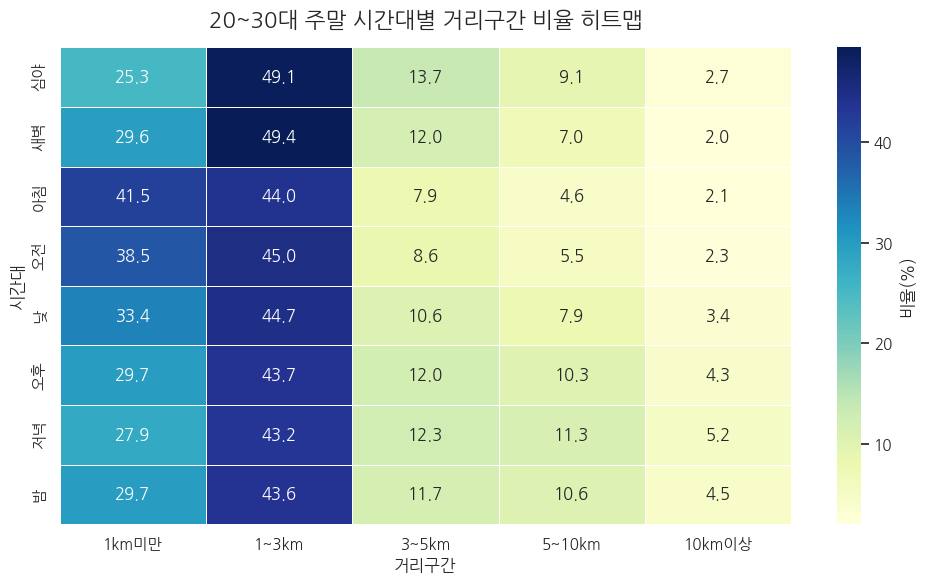

In [ ]:
plot_time_distance_charts(age2030_weekday_time_distance_rate, '20~30대 평일')
plot_time_distance_charts(age2030_weekend_time_distance_rate, '20~30대 주말')

[20~30대 평일 시간대별 거리구간 비율 히트맵]

전연령이 아닌 20 ~ 30대로 한정하여 평일 시간대별 거리구간 비율 히트맵을 확인했다.
- 전연령대 평일 시간대별 히트맵과 비교하여 **아침**과 **오전**의 **1km미만**이 각각 **4%p** 정도의 차이를 보인다.
- 2030의 **등교**, **출퇴근** 등의 이동을 위한 따릉이 이용이 반영된 수치로 판단된다.



[20~30대 주 시간대별 거리구간 비율 히트맵]

20 ~ 30대 주말 시간대별 거리구간 이용 비율을 시각화했다.
- 전연령과 비교했을 시 **아침**, **1km 미만**에서 **5%p** 차이를 확인할 수 있다. 이는 출근 수요의 감소로 추측된다.
- 동일한 대상인 2030대 평일과 비교했을 시에는 **전연령대의 평일에서 주말 변화**와 **유사**한 패턴으로 비율 변화가 관측된다.

### 20대와 30대 분리 분석: 평일/주말 시간대별 거리구간 이용분포

이번 분석에서는 `20대`와 `30대`를 합치지 않고 각각 분리하여 확인한다.  
평일과 주말을 나누고, 시간대별로 거리구간 이용분포를 계산한다.

시각화는 각 시간대 안에서 거리구간별 평균 이용건수가 차지하는 비율(%)로 나타낸다.

In [ ]:
df_time_20 = df_time[df_time['연령대'] == '20대'].copy()

print('20대 데이터 크기:', df_time_20.shape)
display(df_time_20.head())

20대 데이터 크기: (3360, 14)


,대여월,연령대,시간대,대여요일,주말여부,거리구간,이용건수,평균_이용시간,중앙값_이용시간,평균_이용거리_km,중앙값_이용거리_km,평균_속도_kmh,요일명,요일구분
280,1,20대,심야,0,False,1km미만,750,6.31,5.0,0.69,0.72,8.93,월요일,평일
281,1,20대,심야,0,False,1~3km,1515,12.87,10.0,1.74,1.63,9.67,월요일,평일
282,1,20대,심야,0,False,3~5km,367,26.26,23.0,3.80,3.69,9.75,월요일,평일
283,1,20대,심야,0,False,5~10km,150,46.14,38.0,6.68,6.10,10.05,월요일,평일
284,1,20대,심야,0,False,10km이상,34,70.09,61.0,12.77,11.79,11.66,월요일,평일


#### 20대 평일/주말 시간대별 거리구간 이용분포 계산

20대만 대상으로 평일과 주말의 시간대별 거리구간 평균 이용건수 및 비율을 계산한다.

In [ ]:
age20_weekday_time_distance_avg, age20_weekday_time_distance_rate = make_time_distance_tables(df_time_20, '평일')
age20_weekend_time_distance_avg, age20_weekend_time_distance_rate = make_time_distance_tables(df_time_20, '주말')

print('20대 평일 시간대별 거리구간 평균 이용건수')
display(age20_weekday_time_distance_avg.style.format('{:,.1f}'))

print('20대 평일 시간대별 거리구간 비율')
display(age20_weekday_time_distance_rate.style.format('{:.1f}%'))

print('20대 주말 시간대별 거리구간 평균 이용건수')
display(age20_weekend_time_distance_avg.style.format('{:,.1f}'))

print('20대 주말 시간대별 거리구간 비율')
display(age20_weekend_time_distance_rate.style.format('{:.1f}%'))

20대 평일 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,"1,861.5","3,359.9",881.7,541.4,156.6
새벽,811.4,"1,202.9",249.6,143.7,42.7
아침,"9,360.7","8,198.7","1,084.5",413.6,80.8
오전,"6,744.1","6,510.1",970.9,435.4,123.9
낮,"6,147.1","7,341.6","1,385.6",771.6,257.0
오후,"8,327.4","11,090.5","2,449.2","1,625.3",572.3
저녁,"10,324.4","14,113.9","3,250.7","2,523.2","1,039.5"
밤,"6,294.3","8,748.2","2,070.6","1,691.9",658.3


20대 평일 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,27.4%,49.4%,13.0%,8.0%,2.3%
새벽,33.1%,49.1%,10.2%,5.9%,1.7%
아침,48.9%,42.8%,5.7%,2.2%,0.4%
오전,45.6%,44.0%,6.6%,2.9%,0.8%
낮,38.7%,46.2%,8.7%,4.9%,1.6%
오후,34.6%,46.1%,10.2%,6.8%,2.4%
저녁,33.0%,45.2%,10.4%,8.1%,3.3%
밤,32.3%,44.9%,10.6%,8.7%,3.4%


20대 주말 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,880.7,"1,756.1",496.9,324.2,94.9
새벽,309.4,545.0,129.0,74.7,21.4
아침,974.9,985.6,151.8,81.3,35.7
오전,"2,151.8","2,404.5",414.8,242.7,99.0
낮,"2,777.8","3,563.9",774.5,564.3,232.5
오후,"2,977.2","4,311.4","1,126.1",958.7,386.0
저녁,"2,515.3","3,845.2","1,091.7","1,023.6",464.2
밤,"2,090.2","3,109.7",844.6,768.6,319.3


20대 주말 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,24.8%,49.4%,14.0%,9.1%,2.7%
새벽,28.7%,50.5%,11.9%,6.9%,2.0%
아침,43.7%,44.2%,6.8%,3.6%,1.6%
오전,40.5%,45.3%,7.8%,4.6%,1.9%
낮,35.1%,45.0%,9.8%,7.1%,2.9%
오후,30.5%,44.2%,11.5%,9.8%,4.0%
저녁,28.1%,43.0%,12.2%,11.4%,5.2%
밤,29.3%,43.6%,11.8%,10.8%,4.5%


#### 20대 평일 시간대별 거리구간 비율 시각화

20대의 평일 이용분포를 시간대별 거리구간 비율(%) 기준으로 확인한다.

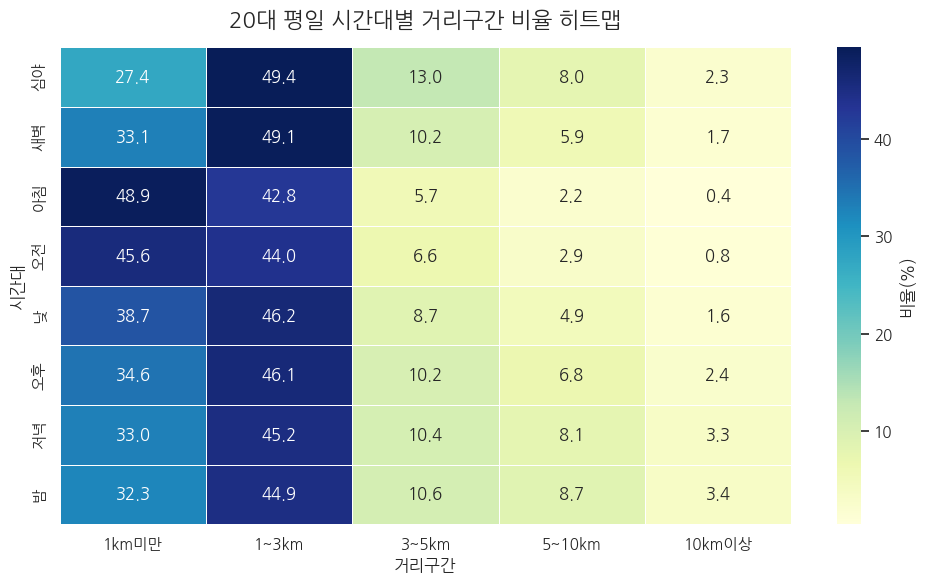

In [ ]:
plot_time_distance_charts(age20_weekday_time_distance_rate, '20대 평일')


[20대 평일 시간대별 거리구간 이용 비율 확인]

- 전체적으로 대부분의 시간대에서 1 ~ 3km 구간의 비율이 가장 높게 나타나고 아침·오전 시간대에는 1km 미만 구간 비율도 높게 나타납니다.
- 특히 아침·오전에는 1km 미만 이용 비율이 1 ~ 3km 구간보다 높은 것으로 보아 평일 오전 시간대에는 매우 짧은 거리의 이동이 상대적으로 많이 발생하는 것이 확인됩니다.
- 낮 이후로는 5km 이상 구간의 비율이 조금씩 증가하는 흐름을 보입니다.
- 5km 이상 장거리 이용은 모든 구간에서 낮은 비중을 차지하므로 20대 평일 이용은 전반적으로 단거리 이동 중심이라고 해석할 수 있습니다.  

#### 20대 주말 시간대별 거리구간 비율 시각화

20대의 주말 이용분포를 시간대별 거리구간 비율(%) 기준으로 확인한다.

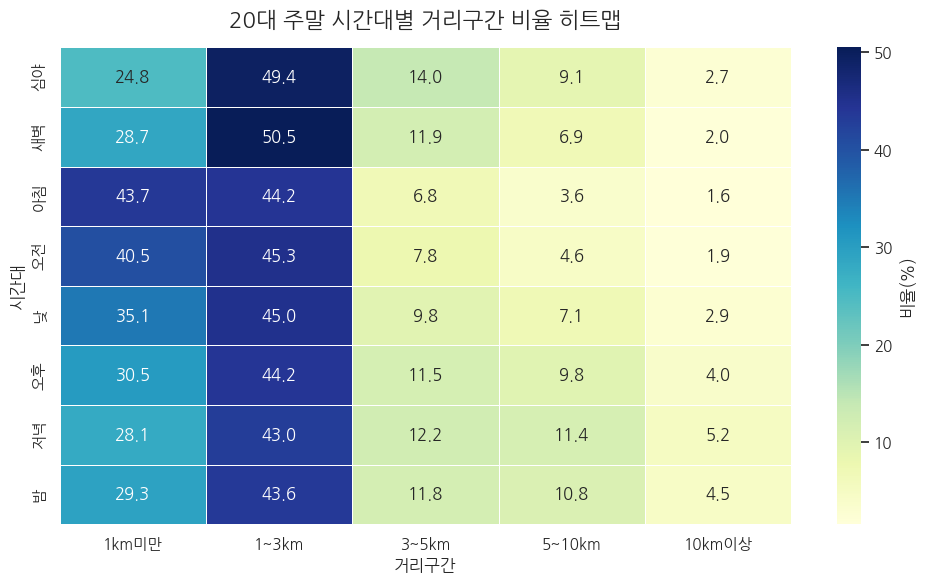

In [ ]:
plot_time_distance_charts(age20_weekend_time_distance_rate, '20대 주말')


[20대 주말 시간대별 거리구간 이용 비율 확인]

- 전체적으로 모든 시간대에서 1 ~ 3km 구간의 비율이 가장 높게 나타나고 그 다음으로 1km 미만 구간의 비율이 높게 나타납니다.
- 주말 오후 이후로는 3km 이상 구간의 비율이 상대적으로 증가하며 특히 저녁에는 장거리 비율이 다른 시간대보다 높게 나타납니다.
- 20대 주말 이용은 전반적으로 단거리 중심이지만 오후에는 비교적 긴 거리의 이용이 늘어나는 흐름을 보인다고 해석할 수 있습니다.

#### 30대 데이터 필터링

In [ ]:
df_time_30 = df_time[df_time['연령대'] == '30대'].copy()

print('30대 데이터 크기:', df_time_30.shape)
display(df_time_30.head())

30대 데이터 크기: (3360, 14)


,대여월,연령대,시간대,대여요일,주말여부,거리구간,이용건수,평균_이용시간,중앙값_이용시간,평균_이용거리_km,중앙값_이용거리_km,평균_속도_kmh,요일명,요일구분
560,1,30대,심야,0,False,1km미만,341,7.85,5.0,0.71,0.75,8.90,월요일,평일
561,1,30대,심야,0,False,1~3km,774,13.36,10.0,1.73,1.64,9.87,월요일,평일
562,1,30대,심야,0,False,3~5km,158,29.77,23.0,3.75,3.65,9.57,월요일,평일
563,1,30대,심야,0,False,5~10km,84,40.02,37.0,6.62,6.24,10.55,월요일,평일
564,1,30대,심야,0,False,10km이상,14,69.50,66.0,12.75,12.76,11.36,월요일,평일


#### 30대 평일/주말 시간대별 거리구간 이용분포 계산

30대만 대상으로 평일과 주말의 시간대별 거리구간 평균 이용건수 및 비율을 계산한다.

In [ ]:
age30_weekday_time_distance_avg, age30_weekday_time_distance_rate = make_time_distance_tables(df_time_30, '평일')
age30_weekend_time_distance_avg, age30_weekend_time_distance_rate = make_time_distance_tables(df_time_30, '주말')

print('30대 평일 시간대별 거리구간 평균 이용건수')
display(age30_weekday_time_distance_avg.style.format('{:,.1f}'))

print('30대 평일 시간대별 거리구간 비율')
display(age30_weekday_time_distance_rate.style.format('{:.1f}%'))

print('30대 주말 시간대별 거리구간 평균 이용건수')
display(age30_weekend_time_distance_avg.style.format('{:,.1f}'))

print('30대 주말 시간대별 거리구간 비율')
display(age30_weekend_time_distance_rate.style.format('{:.1f}%'))

30대 평일 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,"1,100.8","1,822.3",455.6,294.8,86.4
새벽,991.3,"1,180.7",250.4,131.7,41.1
아침,"14,409.2","12,247.8","1,904.8",854.9,183.1
오전,"7,076.9","7,295.9","1,296.6",662.2,181.0
낮,"5,365.6","7,121.9","1,488.3",871.5,284.3
오후,"8,448.6","10,805.6","2,593.7","1,811.0",667.6
저녁,"12,557.1","16,637.1","3,816.8","2,867.7","1,154.0"
밤,"5,454.2","7,177.0","1,675.5","1,296.1",503.8


30대 평일 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,29.3%,48.5%,12.1%,7.8%,2.3%
새벽,38.2%,45.5%,9.6%,5.1%,1.6%
아침,48.7%,41.4%,6.4%,2.9%,0.6%
오전,42.9%,44.2%,7.9%,4.0%,1.1%
낮,35.5%,47.1%,9.8%,5.8%,1.9%
오후,34.7%,44.4%,10.7%,7.4%,2.7%
저녁,33.9%,44.9%,10.3%,7.7%,3.1%
밤,33.9%,44.6%,10.4%,8.0%,3.1%


30대 주말 시간대별 거리구간 평균 이용건수


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,534.6,986.7,268.8,184.8,56.2
새벽,240.7,374.9,94.1,55.6,16.7
아침,"1,019.8","1,127.3",225.8,139.9,65.4
오전,"2,271.0","2,762.9",574.5,390.7,162.2
낮,"2,632.0","3,669.9",934.0,721.4,311.2
오후,"2,746.8","4,098.6","1,194.0","1,026.7",437.7
저녁,"2,316.4","3,628.4","1,038.2",931.3,442.6
밤,"1,526.5","2,203.6",583.4,519.6,224.7


30대 주말 시간대별 거리구간 비율


거리구간,1km미만,1~3km,3~5km,5~10km,10km이상
시간대,,,,,
심야,26.3%,48.6%,13.2%,9.1%,2.8%
새벽,30.8%,47.9%,12.0%,7.1%,2.1%
아침,39.6%,43.7%,8.8%,5.4%,2.5%
오전,36.9%,44.8%,9.3%,6.3%,2.6%
낮,31.8%,44.4%,11.3%,8.7%,3.8%
오후,28.9%,43.1%,12.6%,10.8%,4.6%
저녁,27.7%,43.4%,12.4%,11.1%,5.3%
밤,30.2%,43.6%,11.5%,10.3%,4.4%


#### 30대 평일 시간대별 거리구간 비율 시각화

30대의 평일 이용분포를 시간대별 거리구간 비율(%) 기준으로 확인한다.

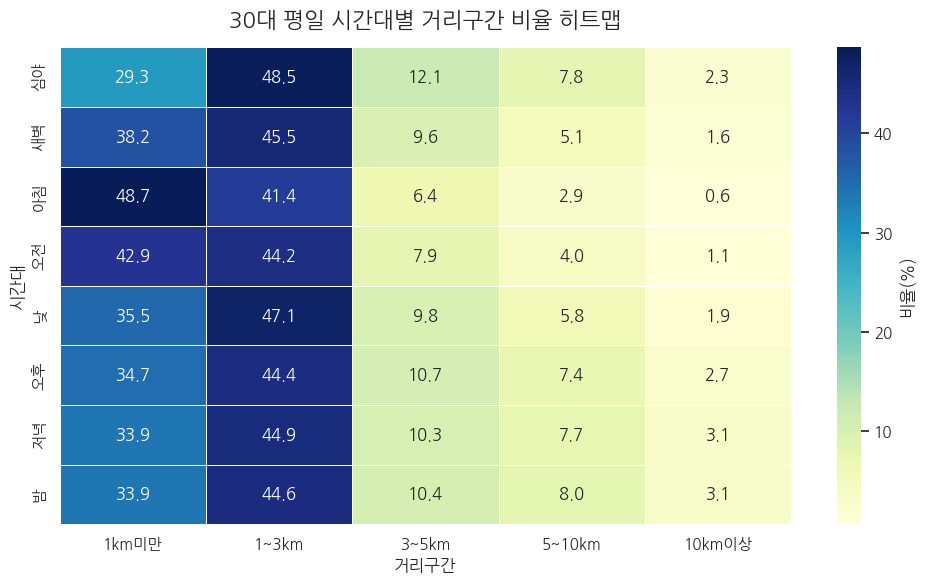

In [ ]:
plot_time_distance_charts(age30_weekday_time_distance_rate, '30대 평일')

[30대 평일 시간대별 거리구간 이용 비율 확인]

- 전체적으로 대부분의 시간대에서 1 ~ 3km 구간의 비율이 가장 높게 나타나고 그 다음으로는 1km 미만 구간의 비율이 높게 나타납니다.
- 아침 시간대에는 1km 미만 이용 비율이 48.7%로 가장 높아 평일 오전에는 매우 짧은 거리의 이동이 상대적으로 많이 발생하는 것으로 확인됩니다.
- 오후 이후로는 3km 이상 구간의 비율이 오전보다 다소 증가하는 흐름을 보입니다.
- 10km 이상 이용은 모든 시간대에서 낮은 비중을 차지하므로 30대 평일 이용은 전반적으로 단거리 이동 중심이라고 해석할 수 있습니다.

#### 30대 주말 시간대별 거리구간 비율 시각화

30대의 주말 이용분포를 시간대별 거리구간 비율(%) 기준으로 확인한다.

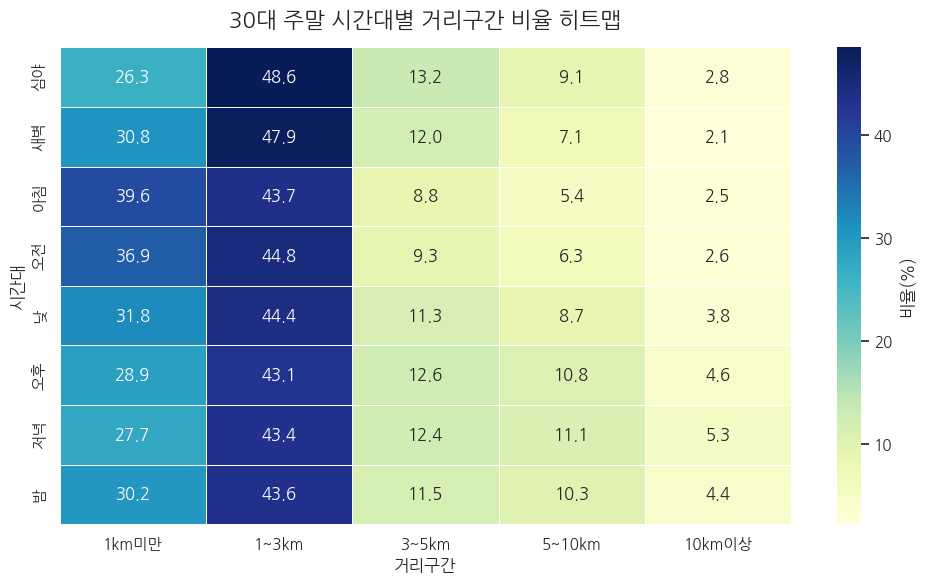

In [ ]:
plot_time_distance_charts(age30_weekend_time_distance_rate, '30대 주말')

[30대 주말 시간대별 거리구간 이용 비율 확인]

- 전체적으로 대부분의 시간대에서 1 ~ 3km 구간의 비율이 가장 높게 나타나고 그 다음으로는 1km 미만 구간의 비율이 높게 나타납니다.
- 시간대별로 오후·저녁·밤으로 갈수록 3km 이상 구간의 비율이 조금씩 증가하는 흐름을 보입니다.
- 30대 주말 이용은 전반적으로 단거리 이동이 중심이지만 오후 이후에는 중·장거리 이용비중이 일부 확대되는 패턴으로 해석할 수 있습니다.


### 20대·30대 단거리/장거리 평일·주말 시간대별 평균 이용건수 비교

20대와 30대를 각각 나누어 단거리와 장거리 이용 패턴을 비교한다.

거리구간은 다음 기준으로 재분류한다.

- 단거리: 0~3km 미만
- 중거리: 3~5km 미만
- 장거리: 5km 이상

이번 분석에서는 단거리와 장거리만 사용한다.  
Y축 단위는 `평균 이용건수(건)`이며, 백 단위로 변환하지 않은 실제 건수 기준이다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from matplotlib.ticker import FuncFormatter

# 분석 기준 설정
time_order = ['심야', '새벽', '아침', '오전', '낮', '오후', '저녁', '밤']

# 원본 데이터 복사
df_line = df.copy()
df_line.columns = df_line.columns.str.strip()

# 기본 컬럼 정리
df_line['대여월'] = pd.to_numeric(df_line['대여월'], errors='coerce')
df_line['대여요일'] = pd.to_numeric(df_line['대여요일'], errors='coerce')
df_line['이용건수'] = pd.to_numeric(df_line['이용건수'], errors='coerce').fillna(0)

df_line['연령대'] = df_line['연령대'].astype(str).str.strip()
df_line['시간대'] = df_line['시간대'].astype(str).str.strip()
df_line['거리구간'] = df_line['거리구간'].astype(str).str.strip()

# 거리구간 표기 통일
df_line['거리구간'] = df_line['거리구간'].replace({
    '10km 이상': '10km이상'
})

# 평일/주말 구분
df_line['요일구분'] = np.where(df_line['대여요일'].isin([5, 6]), '주말', '평일')

# 거리구간 재분류
distance_group_map = {
    '1km미만': '단거리',
    '1~3km': '단거리',
    '3~5km': '중거리',
    '5~10km': '장거리',
    '10km이상': '장거리'
}

df_line['거리대분류'] = df_line['거리구간'].map(distance_group_map)
df_line['시간대'] = pd.Categorical(df_line['시간대'], categories=time_order, ordered=True)

display(df_line.head())

,대여월,연령대,시간대,대여요일,주말여부,거리구간,이용건수,평균_이용시간,중앙값_이용시간,평균_이용거리_km,중앙값_이용거리_km,평균_속도_kmh,요일명,요일구분,거리대분류
0,1,10대이하,심야,0,False,1km미만,113,8.59,5.0,0.67,0.74,8.03,월요일,평일,단거리
1,1,10대이하,심야,0,False,1~3km,263,14.45,12.0,1.80,1.73,9.05,월요일,평일,단거리
2,1,10대이하,심야,0,False,3~5km,64,27.91,24.0,3.85,3.76,9.50,월요일,평일,중거리
3,1,10대이하,심야,0,False,5~10km,43,53.12,44.0,6.65,6.40,8.83,월요일,평일,장거리
4,1,10대이하,심야,0,False,10km이상,6,79.00,77.5,12.10,12.40,9.65,월요일,평일,장거리


#### 평일/주말 실제 날짜 수 계산

평균 이용건수는 단순 합계가 아니라 실제 날짜 수로 나누어 계산한다.

- 평일 평균 이용건수 = 평일 전체 이용건수 / 평일 실제 날짜 수
- 주말 평균 이용건수 = 주말 전체 이용건수 / 주말 실제 날짜 수

In [ ]:
analysis_year = 2025
months = sorted(df_line['대여월'].dropna().astype(int).unique())

day_count_list = []

for month in months:
    last_day = calendar.monthrange(analysis_year, month)[1]
    dates = pd.date_range(
        start=f'{analysis_year}-{month:02d}-01',
        end=f'{analysis_year}-{month:02d}-{last_day}'
    )

    for date in dates:
        weekday_num = date.weekday()
        day_count_list.append({
            '날짜': date,
            '요일구분': '주말' if weekday_num in [5, 6] else '평일'
        })

day_count_df = pd.DataFrame(day_count_list)

period_day_count = (
    day_count_df
    .groupby('요일구분')
    .size()
    .reset_index(name='실제_날짜수')
)

display(period_day_count)

,요일구분,실제_날짜수
0,주말,104
1,평일,261


#### 평일/주말 시간대별 평균 이용건수 표 생성 함수

연령대와 거리구분을 입력하면, 평일과 주말의 시간대별 평균 이용건수 표를 생성한다.

표의 값은 `건수` 단위이며, 각 시간대별 하루 평균 이용건수를 의미한다.

In [ ]:
def make_period_time_avg_table(data, age_group, distance_group):
    temp = data[
        (data['연령대'] == age_group) &
        (data['거리대분류'] == distance_group)
    ].copy()

    total_table = (
        temp
        .groupby(['요일구분', '시간대'], observed=False)['이용건수']
        .sum()
        .reset_index()
    )

    avg_table = total_table.merge(
        period_day_count,
        on='요일구분',
        how='left'
    )

    avg_table['평균_일별_이용건수'] = (
        avg_table['이용건수'] / avg_table['실제_날짜수']
    )

    result = (
        avg_table
        .pivot(index='시간대', columns='요일구분', values='평균_일별_이용건수')
        .reindex(index=time_order, columns=['평일', '주말'])
        .fillna(0)
    )

    return result

#### 비교용 표 생성

20대 단거리, 30대 단거리, 20대 장거리, 30대 장거리의 평일/주말 시간대별 평균 이용건수 표를 생성한다.

In [ ]:
age20_short_table = make_period_time_avg_table(df_line, '20대', '단거리')
age30_short_table = make_period_time_avg_table(df_line, '30대', '단거리')

age20_long_table = make_period_time_avg_table(df_line, '20대', '장거리')
age30_long_table = make_period_time_avg_table(df_line, '30대', '장거리')

print('20대 단거리 평일/주말 시간대별 평균 이용건수')
display(age20_short_table.style.format('{:,.1f}'))

print('30대 단거리 평일/주말 시간대별 평균 이용건수')
display(age30_short_table.style.format('{:,.1f}'))

print('20대 장거리 평일/주말 시간대별 평균 이용건수')
display(age20_long_table.style.format('{:,.1f}'))

print('30대 장거리 평일/주말 시간대별 평균 이용건수')
display(age30_long_table.style.format('{:,.1f}'))

20대 단거리 평일/주말 시간대별 평균 이용건수


요일구분,평일,주말
시간대,,
심야,"1,044.3","1,318.4"
새벽,402.9,427.2
아침,"3,512.6",980.3
오전,"2,651.0","2,278.1"
낮,"2,697.6","3,170.9"
오후,"3,883.1","3,644.3"
저녁,"4,887.6","3,180.3"
밤,"3,008.7","2,599.9"


30대 단거리 평일/주말 시간대별 평균 이용건수


요일구분,평일,주말
시간대,,
심야,584.7,760.7
새벽,434.5,307.8
아침,"5,332.6","1,073.6"
오전,"2,874.7","2,516.9"
낮,"2,497.3","3,150.9"
오후,"3,850.5","3,422.7"
저녁,"5,839.0","2,972.4"
밤,"2,526.5","1,865.0"


20대 장거리 평일/주말 시간대별 평균 이용건수


요일구분,평일,주말
시간대,,
심야,139.6,209.5
새벽,37.3,48.0
아침,98.9,58.5
오전,111.9,170.8
낮,205.7,398.4
오후,439.5,672.3
저녁,712.5,743.9
밤,470.0,544.0


30대 장거리 평일/주말 시간대별 평균 이용건수


요일구분,평일,주말
시간대,,
심야,76.2,120.5
새벽,34.6,36.2
아침,207.7,102.6
오전,168.7,276.5
낮,231.1,516.3
오후,495.7,732.2
저녁,804.3,686.9
밤,360.0,372.2


#### Y축 범위 통일

20대와 30대 그래프를 비교하기 쉽도록 Y축 최댓값을 맞춘다.

- 단거리 그래프 2개는 같은 Y축 범위 사용
- 장거리 그래프 2개는 같은 Y축 범위 사용

In [ ]:
short_y_max = max(
    age20_short_table.max().max(),
    age30_short_table.max().max()
) * 1.1

long_y_max = max(
    age20_long_table.max().max(),
    age30_long_table.max().max()
) * 1.1

print(f'단거리 그래프 Y축 최대값: {short_y_max:,.1f}건')
print(f'장거리 그래프 Y축 최대값: {long_y_max:,.1f}건')

단거리 그래프 Y축 최대값: 6,422.9건
장거리 그래프 Y축 최대값: 884.8건


#### 선 그래프 생성 함수

평일과 주말의 시간대별 평균 이용건수를 선 그래프로 나타낸다.  
Y축 단위는 `평균 이용건수(건)`이다.

In [ ]:
def plot_period_time_line(table, title, y_max):
    plt.figure(figsize=(11, 5))

    plt.plot(
        table.index.astype(str),
        table['평일'],
        marker='o',
        linewidth=2.5,
        label='평일'
    )

    plt.plot(
        table.index.astype(str),
        table['주말'],
        marker='o',
        linewidth=2.5,
        label='주말'
    )

    plt.title(title, fontsize=16, pad=15)
    plt.xlabel('시간대')
    plt.ylabel('평균 이용건수(건)')
    plt.ylim(0, y_max)
    plt.grid(True, alpha=0.3)
    plt.legend(title='요일구분')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

#### 20대 단거리 평일·주말 시간대별 평균 이용건수 선 그래프

20대 단거리 이용의 평일과 주말 시간대별 평균 이용건수를 확인한다.  
30대 단거리 그래프와 비교할 수 있도록 Y축 범위를 동일하게 설정한다.

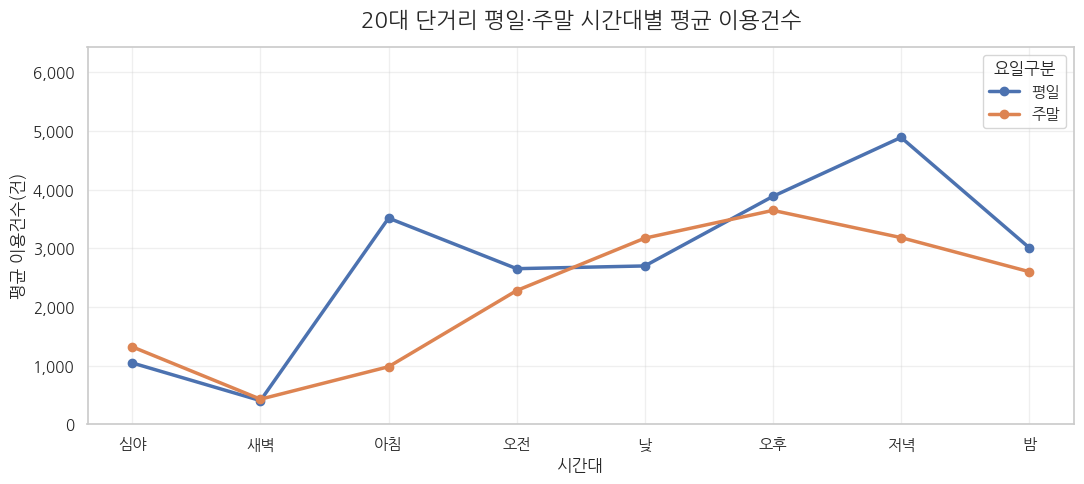

In [ ]:
plot_period_time_line(
    age20_short_table,
    '20대 단거리 평일·주말 시간대별 평균 이용건수',
    short_y_max
)

[20대 단거리 이용의 평일·주말 시간대별 평균 이용건수 확인]

- 평일은 아침과 저녁 시간대의 이용건수가 높게 나타나며, 특히 저녁 시간대 평균 이용건수가 가장 높다.
- 주말은 오후 시간대에 가장 높고, 새벽부터 오후까지 이용이 증가하는 흐름을 보인다.


#### 30대 단거리 평일·주말 시간대별 평균 이용건수 선 그래프

30대 단거리 이용의 평일과 주말 시간대별 평균 이용건수를 확인한다.  
20대 단거리 그래프와 비교할 수 있도록 Y축 범위를 동일하게 설정한다.

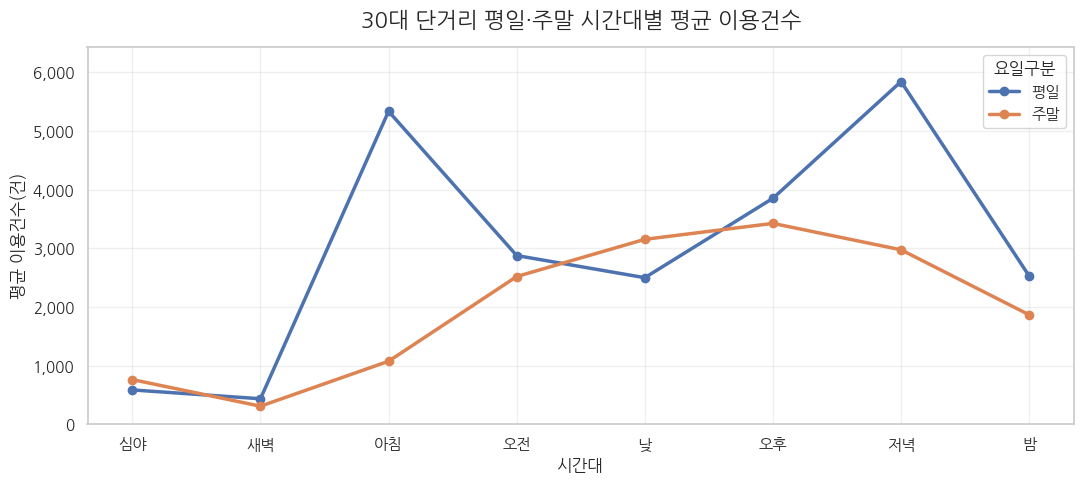

In [ ]:
plot_period_time_line(
    age30_short_table,
    '30대 단거리 평일·주말 시간대별 평균 이용건수',
    short_y_max
)

[30대 단거리 이용의 평일·주말 시간대별 평균 이용건수 확인]

- 평일은 아침과 저녁 시간대의 이용건수가 뚜렷하게 높게 나타났으며, 특히 저녁 시간대에 가장 높은 값을 보인다.
- 주말은 오후 시간대에 이용건수가 가장 높고, 그 이후로는 감소하는 흐름을 보인다.


#### 20대 장거리 평일·주말 시간대별 평균 이용건수 선 그래프

20대 장거리 이용의 평일과 주말 시간대별 평균 이용건수를 확인한다.  
30대 장거리 그래프와 비교할 수 있도록 Y축 범위를 동일하게 설정한다.

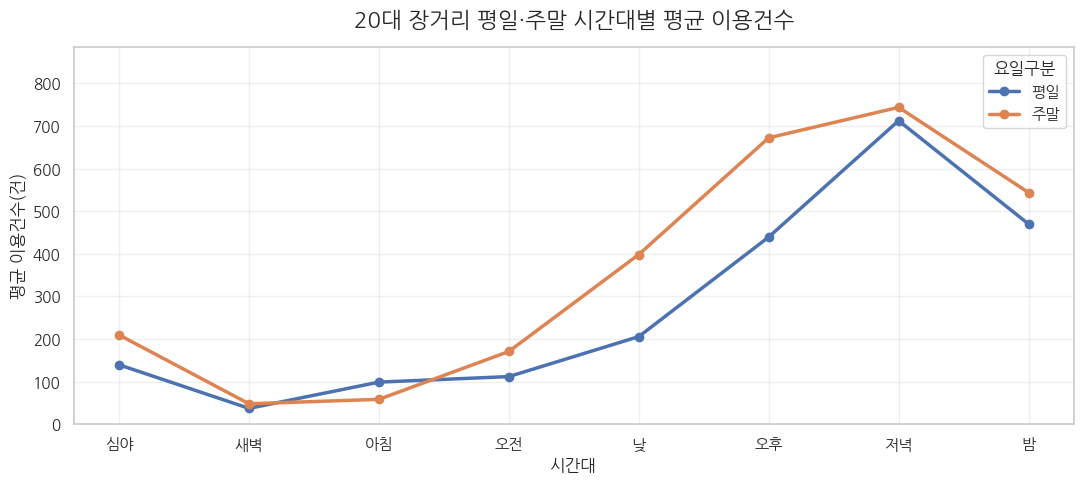

In [ ]:
plot_period_time_line(
    age20_long_table,
    '20대 장거리 평일·주말 시간대별 평균 이용건수',
    long_y_max
)

[20대 장거리 이용의 평일·주말 시간대별 평균 이용건수 확인]

- 평일과 주말 모두 저녁 시간대의 이용건수가 가장 높게 나타났으며, 주말은 오전부터 오후까지 이용건수가 꾸준히 증가하는 흐름을 보인다.
- 특히 주말은 낮과 오후 시간대에서 평일보다 높은 이용건수를 보여 20대의 장거리 이용은 주말에 더 활발한 것으로 확인됩니다.
- 단거리 이용이 평일 아침·저녁에 뚜렷했던 것과 다르게 장거리 이용은 오전 이후부터 저녁까지 증가하는 패턴을 보인다.
- 하지만 시간대별 이용건수만으로 실제 이용 목적을 확정할 수 없으므로 여가·운동 목적과 관련이 있다 정도로 해석할 수 있습니다.


#### 30대 장거리 평일·주말 시간대별 평균 이용건수 선 그래프

30대 장거리 이용의 평일과 주말 시간대별 평균 이용건수를 확인한다.  
20대 장거리 그래프와 비교할 수 있도록 Y축 범위를 동일하게 설정한다.

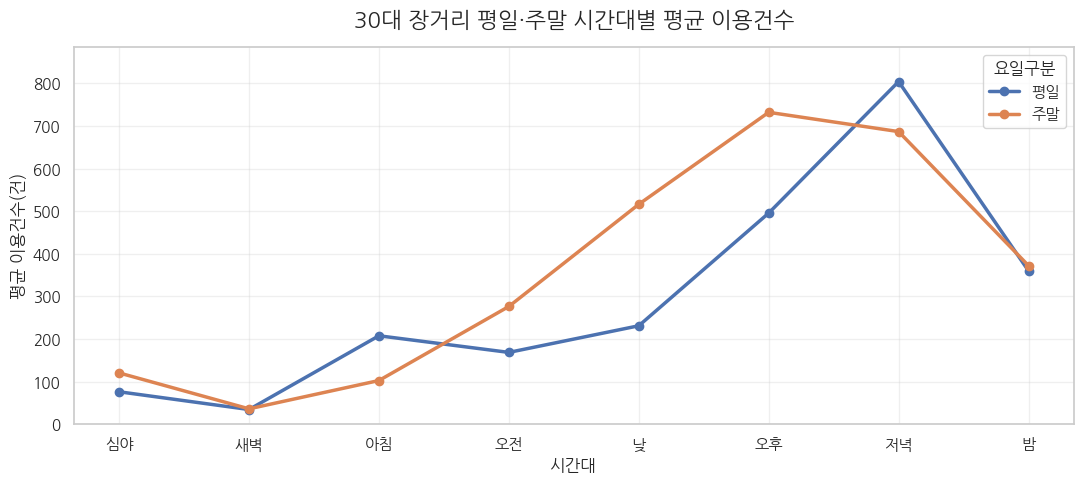

In [ ]:
plot_period_time_line(
    age30_long_table,
    '30대 장거리 평일·주말 시간대별 평균 이용건수',
    long_y_max
)

[30대 장거리 이용의 평일·주말 시간대별 평균 이용건수 확인]

- 평일은 저녁 시간대의 이용건수가 가장 높게 나타나며, 낮부터 저녁까지 이용건수가 크게 증가하는 흐름을 보인다.
- 주말은 아침부터 오후까지 이용건수가 빠르게 증가하고 오후 시간대에 가장 높은 값을 보인다.
- 특히 주말은 낮부터 오후까지 평일보다 높은 이용건수를 통해 30대의 장가리 이용은 주말 낮 이후에 더 활발하게 나타나는 것으로 확인됩니다.
- 하지만 시간대별 이용건수만으로 실제 이용 목적을 확정할 수 없으므로 주말 낮·오후 장거리 이용은 여가·운동 목적과 관련이 있다 정도로 해석할 수 있습니다.